In [1]:
import re
import glob
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pickle

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import make_scorer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn import svm

In [2]:
def process_text(input_file, output_file):
    output_text = []
    with open(input_file, 'r') as f:
        text = f.read()

    # Remove soft hyphen characters
    text = text.replace('\xad', '')
    text = text.replace('\u2009', ' ')
    # Remove spaces before ! and ? characters
    text = re.sub(r'\s+([!?])', r'\1', text)
    text = re.sub(r'\s*\*\s*', '', text)
    # Split text into paragraphs based on empty lines
    paragraphs = re.split(r'\n\s*\n', text)
    
    with open(output_file, 'w') as f:
        for paragraph in paragraphs:
            # Ignore lines starting with <
            lines = paragraph.split('\n')
            filtered_lines = [line.strip() for line in lines if not line.startswith('<')]
            paragraph = ' '.join(filtered_lines)
            
            # Split paragraph into sentences
            sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z])', paragraph)
            
            for sentence in sentences:
                # Write each sentence on a single line
                f.write(sentence + '\n')
                sentence = re.sub(r'^\s*[0-9IVXL\.]+\s*$', '', sentence)
                if sentence != '':
                    output_text.append(sentence)
            f.write('\n')
            
    return output_text


def process_text_sig(input_file, output_file):
    output_text = []
    with open(input_file, 'r', encoding='utf-8-sig') as f:
        text = f.read()

    text = text.replace('\xa0', ' ')
    # Remove soft hyphen characters
    text = text.replace('\xad', '')
    # Remove spaces before ! and ? characters
    text = re.sub(r'\s+([!?])', r'\1', text)
    text = re.sub(r'\s*\*\s*', '', text)
    
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Split text into paragraphs based on empty lines
    paragraphs = re.split(r'\n\s*\n', text)

    with open(output_file, 'w') as f:
        for paragraph in paragraphs:
            # Ignore lines starting with <
            lines = paragraph.split('\n')
            filtered_lines = [line.strip() for line in lines if not line.startswith('<')]
            paragraph = ' '.join(filtered_lines)
            
            # Split paragraph into sentences
            sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z])', paragraph)
            
            for sentence in sentences:
                # Write each sentence on a single line
                f.write(sentence + '\n')
                sentence = re.sub(r'^\s*[0-9IVXL\.]+\s*$', '', sentence)
                if sentence != '':
                    output_text.append(sentence)
            f.write('\n')
            
    return output_text


def count_words_per_sentence(line):
    # Split the line into words based on spaces and dashes
    words = re.split(r'\s+', line)

    # Filter out words that consist solely of dashes
    words_without_dashes = [word for word in words if not re.match(r'^[\-\–\—]+$', word)]

    # Count the number of words without dashes
    num_words = len(words_without_dashes)

    return num_words


def count_words_per_text(text):
    total_num_words = 0
    
    for sentence in text:
        num_words = count_words_per_sentence(sentence)
        total_num_words += num_words
        
    return total_num_words


def split_to_chunks(output_text, chunk_length=1000, allowed_tail_fraction=0.3):
    text_length = count_words_per_text(output_text)
    if text_length < chunk_length:
        return [output_text]
    
    th = text_length // chunk_length
    delta = (th + 1) * chunk_length - text_length
    slider = delta // th + 1
    if slider > allowed_tail_fraction * chunk_length:
        slider = 0
    
    gathered_words = 0
    curr_chunk = []
    num_chunks = 0
    arr_chunks = []

    i = 0
    while i < len(output_text):
        while (gathered_words <= chunk_length) and (i < len(output_text)):
            sentence = output_text[i]
            curr_chunk.append(sentence)
            gathered_words += count_words_per_sentence(sentence)
            i += 1
            if gathered_words < chunk_length - slider:
                marked_i = i
            
        if gathered_words > (1 - allowed_tail_fraction) * chunk_length:
            arr_chunks.append(curr_chunk)
        else:
            pass
        num_chunks += 1
        if num_chunks > th:
            break
        gathered_words = 0
        curr_chunk = []
        i = marked_i + 1
        
    return arr_chunks


def generate_random_integers(n, n1, n2, span, random_seed=42):
    integers = []

    # Generate N random integers within the range [n1, n2]
    random.seed(random_seed)
    for _ in range(n):
        integers.append(random.randint(n1, n2))

    # Sort the integers
    integers.sort()

    return integers


def sparse_split_to_chunks(output_text, chunk_length=1000, fractions=8):
    text_length = count_words_per_text(output_text)
    if text_length < chunk_length:
        return output_text
    
    th = text_length // chunk_length
    num_sent = len(output_text)
    
    chunks2generate = generate_random_integers(th // fractions + 1, 0, num_sent, num_sent // fractions)
    
    gathered_words = 0
    curr_chunk = []
    num_chunks = 0
    arr_chunks = []

    i = 0
    while i < len(output_text):
        while (gathered_words <= chunk_length) and (i < len(output_text)):
            sentence = output_text[i]
            curr_chunk.append(sentence)
            gathered_words += count_words_per_sentence(sentence)
            i += 1

        if gathered_words >= chunk_length:
            arr_chunks.append(curr_chunk)

        num_chunks += 1
        if num_chunks >= len(chunks2generate):
            break
        gathered_words = 0
        curr_chunk = []
        i = chunks2generate[num_chunks]
        
    return arr_chunks

In [3]:
ngram_min, ngram_max = 2, 2
proportion, fraction = 64, 20
proportion, fraction = 78, 10
proportion, fraction = 87, 5

chunk_length = 200
allowed_tail_fraction = 0.0

corpus_Franko = []
length_Franko = []
source_Franko = []

# Specify the file pattern (e.g., '*.txt' for all text files)
file_pattern = 'txt/franko/franko-*.txt'
prefix, suffix = file_pattern.split('*')

text_name_arr, text_length_arr = [], []

# Iterate over files matching the pattern
for file_path in sorted(glob.glob(file_pattern)):
    input_file = file_path
    output_file = 'processed_'
    output_text = process_text(input_file, output_file)
    text_length = count_words_per_text(output_text)
    text_name = file_path.replace(prefix, '').replace(suffix, '')
    print(f'{text_length:6} {text_name}')
    
    text_name_arr.append(text_name)
    text_length_arr.append(text_length)

    arr_chunks = split_to_chunks(output_text, chunk_length=chunk_length, 
                                 allowed_tail_fraction=allowed_tail_fraction)
    
    for chunk in arr_chunks:
        sample = ' '.join(chunk)
        corpus_Franko.append(sample)
        num_words = count_words_per_text(chunk)
        length_Franko.append(num_words)
        source_Franko.append(text_name)

df_Franko = pd.DataFrame({'Text': corpus_Franko, 'Words': length_Franko, 'Source': source_Franko})
df_Franko['Author'] = 'Franko'

df_Franko_texts = pd.DataFrame({'Text_name': text_name_arr, 'Text_length': text_length_arr})
df_Franko_texts = df_Franko_texts.sort_values(by='Text_length', ascending=False).reset_index(drop=True)
display(df_Franko_texts)

  1814 bajka_o_dobrobycie
  4503 bohater_mimo_woli
  3622 chlopska_komisya
  4946 cuwaksy
  3327 cyganie
  1954 czlowiek_zwyczajny
 43793 dla_ogniska_domowego
  1506 dobry_zarobek
  3242 dwaj_przyjaciele
  8417 dzuma
  6977 hawa
  1506 historja_kozucha
  2580 historya_mojej_sieczkarni
  1979 hrycio_w_szkole
  9119 jac_zelepuha
  3055 jak_rusin_tlukl_sie
  4569 jeden_dzien_z_zycia
 53501 lelum_i_polelum4-10
 16316 manipulantka
  1927 mloda_rus
  1666 murarz
 17741 na_dnie
  4439 olowek
  1703 owczarz
 16267 pantalacha
  2152 patrjotyczne_porywy
  1151 pojedynek
  2648 przemysl_domowy
  2287 rebacz
  2657 sam_sobie_winien
   754 sen_robotnika
  2618 slimak
  7406 w_pogoni_za_bieda
  1824 zniechecony


,Text_name,Text_length
0,lelum_i_polelum4-10,53501
1,dla_ogniska_domowego,43793
2,na_dnie,17741
3,manipulantka,16316
4,pantalacha,16267
5,jac_zelepuha,9119
6,dzuma,8417
7,w_pogoni_za_bieda,7406
8,hawa,6977
9,cuwaksy,4946


In [4]:
n_splits = 5

# Assign initial group numbers to the first N texts
for i in range(n_splits):
    df_Franko_texts.loc[i, 'Fold'] = i

# Calculate the average length per group
total_length = df_Franko_texts['Text_length'].sum()

average_length_per_group = total_length / n_splits

print('Total length:', total_length, 'Average length:', average_length_per_group)

# Add remaining texts to groups while keeping total lengths more or less equal
for i in range(n_splits, len(df_Franko_texts)):
    # Calculate the current total length of each group
    group_lengths = df_Franko_texts.groupby('Fold')['Text_length'].sum().tolist()
    
    # Find the group with the minimum total length
    min_group_index = np.argmin(group_lengths)
    
    # Add the current text to this group
    df_Franko_texts.loc[i, 'Fold'] = min_group_index

# Print lengths of all groups
group_lengths = df_Franko_texts.groupby('Fold')['Text_length'].sum().tolist()
for i, length in enumerate(group_lengths):
    print(f"Fold {i}: Total Length = {length}")

df_Franko_texts['Fold'] = df_Franko_texts['Fold'].astype(int)
display(df_Franko_texts)

Total length: 243966 Average length: 48793.2
Fold 0: Total Length = 53501
Fold 1: Total Length = 47123
Fold 2: Total Length = 47819
Fold 3: Total Length = 47504
Fold 4: Total Length = 48019


,Text_name,Text_length,Fold
0,lelum_i_polelum4-10,53501,0
1,dla_ogniska_domowego,43793,1
2,na_dnie,17741,2
3,manipulantka,16316,3
4,pantalacha,16267,4
5,jac_zelepuha,9119,4
6,dzuma,8417,3
7,w_pogoni_za_bieda,7406,2
8,hawa,6977,3
9,cuwaksy,4946,2


In [5]:
display(df_Franko)
df_Franko['Words'].sum()

,Text,Words,Source,Author
0,Był tu sobie kiedyś Dobrobyt. Nie wiem czy kto...,208,bajka_o_dobrobycie,Franko
1,Chodzi sobie i wyśpiewuje na całe gardło: Weso...,212,bajka_o_dobrobycie,Franko
2,Pierwszy raz w życiu naszemu Dobrobytowi zasze...,201,bajka_o_dobrobycie,Franko
3,— Ba... ba... a to jakiem prawem? — wybełkotał...,201,bajka_o_dobrobycie,Franko
4,"A po zboże jeszcze dziś wyszlę fury, by je zab...",202,bajka_o_dobrobycie,Franko
...,...,...,...,...
1136,"Nastąpiły dla niego ciężkie czasy. Pomoc, jaką...",266,zniechecony,Franko
1137,"Ten ostatni sposób życia w wiecznej gościnie, ...",209,zniechecony,Franko
1138,"Nigdy nie zadowolona żądza, wieczne zawody, ro...",222,zniechecony,Franko
1139,"Może to jakoś będzie“, ta myśl zastąpiła, u ni...",207,zniechecony,Franko


241517

In [6]:
# Specify the file pattern (e.g., '*.txt' for all text files)
file_pattern = 'txt/100_polish_novels/corpus/*.txt'
prefix, suffix = file_pattern.split('*')

corpus_Other = []
length_Other = []
source_Other = []

text_name_arr, text_length_arr = [], []

# Iterate over files matching the pattern
for file_path in sorted(glob.glob(file_pattern)):
    input_file = file_path
    output_file = '_processed_'
    output_text = process_text(input_file, output_file)
    text_length = count_words_per_text(output_text)
    text_name = file_path.replace(prefix, '').replace(suffix, '')
    print(f'{text_length:6} {text_name}')
    
    text_name_arr.append(text_name)
    text_length_arr.append(text_length)
    
    arr_chunks = sparse_split_to_chunks(output_text, chunk_length=chunk_length, fractions=fraction)
    
    for chunk in arr_chunks:
        sample = ' '.join(chunk)
        corpus_Other.append(sample)
        num_words = count_words_per_text(chunk)
        length_Other.append(num_words)
        source_Other.append(text_name)

df_Other = pd.DataFrame({'Text': corpus_Other, 'Words': length_Other, 'Source': source_Other})
df_Other['Author'] = 'Other'

df_Other_texts = pd.DataFrame({'Text_name': text_name_arr, 'Text_length': text_length_arr})
df_Other_texts = df_Other_texts.sort_values(by='Text_length', ascending=False).reset_index(drop=True)
display(df_Other_texts)

 32596 balucki_burmistrz_1887
 66055 balucki_murzyn_1875
 49119 balucki_przebudzeni_1864
 35606 beczkowska_bedzie_1897
 82929 beczkowska_droga_1898
 54098 beczkowska_gniezdzie_1899
 39198 berent_diogenes_1937
 77954 berent_kamienie_1918
 75173 berent_prochno_1903
 76565 dabrowska_nocednie1_1931
 71267 dabrowska_nocednie2_1932
178074 dabrowska_nocednie3_1933
 68633 deotyma_panienka_1893
 79421 deotyma_rozdrozu_1877
 45580 deotyma_zagadka_1879
132825 dmochowska_dwor_1903
 58691 dmochowska_obraczka_1907
 50581 dmochowska_odlamana_1914
 53535 domanska_historia_1913
 31698 domanska_krysia_1914
 40682 domanska_paziowie_1910
 41073 dygasinski_as_1896
 86374 dygasinski_piszczalski_1890
 15390 dygasinski_wilk_1883
 90104 godlewska_kato_1897
 24429 godlewska_kwiat_1897
 14783 godlewska_ninka_1897
 73680 gojawiczynska_dziewczeta_1935
111187 gojawiczynska_jablon_1937
 67548 gojawiczynska_ziemia_1934
105954 iwaszkiewicz_czerwone_1934
 21973 iwaszkiewicz_mlyn_1936
 18250 iwaszkiewicz_panny_1932
1930

,Text_name,Text_length
0,reymont_chlopi_1908,305906
1,kaczkowski_olbrachtowi_1889,265020
2,prus_emancypantki_1894,249835
3,prus_lalka_1890,248676
4,sienkiewicz_ogniem_1884,239074
...,...,...
95,zapolska_smierc_1911,20619
96,iwaszkiewicz_panny_1932,18250
97,dygasinski_wilk_1883,15390
98,godlewska_ninka_1897,14783


In [7]:
n_splits = 5

# Assign initial group numbers to the first N texts
for i in range(n_splits):
    df_Other_texts.loc[i, 'Fold'] = n_splits - 1 - i

# Calculate the average length per group
total_length = df_Other_texts['Text_length'].sum()

average_length_per_group = total_length / n_splits

print('Total length:', total_length, 'Average length:', average_length_per_group)

# Add remaining texts to groups while keeping total lengths more or less equal
for i in range(n_splits, len(df_Other_texts)):
    # Calculate the current total length of each group
    group_lengths = df_Other_texts.groupby('Fold')['Text_length'].sum().tolist()
    
    # Find the group with the minimum total length
    min_group_index = np.argmin(group_lengths)
    
    # Add the current text to this group
    df_Other_texts.loc[i, 'Fold'] = min_group_index

# Print lengths of all groups
group_lengths = df_Other_texts.groupby('Fold')['Text_length'].sum().tolist()
for i, length in enumerate(group_lengths):
    print(f"Fold {i}: Total Length = {length}")

df_Other_texts['Fold'] = df_Other_texts['Fold'].astype(int)
display(df_Other_texts)

Total length: 8383640 Average length: 1676728.0
Fold 0: Total Length = 1679324
Fold 1: Total Length = 1673329
Fold 2: Total Length = 1679374
Fold 3: Total Length = 1674823
Fold 4: Total Length = 1676790


,Text_name,Text_length,Fold
0,reymont_chlopi_1908,305906,4
1,kaczkowski_olbrachtowi_1889,265020,3
2,prus_emancypantki_1894,249835,2
3,prus_lalka_1890,248676,1
4,sienkiewicz_ogniem_1884,239074,0
...,...,...,...
95,zapolska_smierc_1911,20619,4
96,iwaszkiewicz_panny_1932,18250,3
97,dygasinski_wilk_1883,15390,1
98,godlewska_ninka_1897,14783,2


In [8]:
display(df_Other)
df_Other['Words'].sum()

,Text,Words,Source,Author
0,Przede wszystkim muszę uprzedzić z góry czytel...,204,balucki_burmistrz_1887,Other
1,W ogóle wszystkie takie wspólne wystąpienia dw...,231,balucki_burmistrz_1887,Other
2,I tak np. gdy szewcy oprócz słuchania mszy świ...,215,balucki_burmistrz_1887,Other
3,Ale zdunowie i pod tym względem nie dali się p...,216,balucki_burmistrz_1887,Other
4,"O ile w szkołach był nieradny i leniwy, o tyle...",227,balucki_burmistrz_1887,Other
...,...,...,...,...
8406,"Bezcelowość zamierzonego czynu, bezcelowość wo...",224,zulawski_zwyciezca_1910,Other
8407,"Szli kupcy i oddzielnie ci, którzy ziemie posi...",212,zulawski_zwyciezca_1910,Other
8408,I tu jednak niedługo pozostawiono go w spokoju...,222,zulawski_zwyciezca_1910,Other
8409,"Zresztą bybardzo może, iż żyjąc dłużej, dałby ...",268,zulawski_zwyciezca_1910,Other


1817829

In [9]:
fold_mapping = df_Franko_texts.set_index('Text_name')['Fold'].to_dict()

# Map the 'Source' values to 'Fold' values
df_Franko['Fold'] = df_Franko['Source'].map(fold_mapping)
display(df_Franko)

fold_mapping = df_Other_texts.set_index('Text_name')['Fold'].to_dict()

# Map the 'Source' values to 'Fold' values
df_Other['Fold'] = df_Other['Source'].map(fold_mapping)
display(df_Other)

,Text,Words,Source,Author,Fold
0,Był tu sobie kiedyś Dobrobyt. Nie wiem czy kto...,208,bajka_o_dobrobycie,Franko,4
1,Chodzi sobie i wyśpiewuje na całe gardło: Weso...,212,bajka_o_dobrobycie,Franko,4
2,Pierwszy raz w życiu naszemu Dobrobytowi zasze...,201,bajka_o_dobrobycie,Franko,4
3,— Ba... ba... a to jakiem prawem? — wybełkotał...,201,bajka_o_dobrobycie,Franko,4
4,"A po zboże jeszcze dziś wyszlę fury, by je zab...",202,bajka_o_dobrobycie,Franko,4
...,...,...,...,...,...
1136,"Nastąpiły dla niego ciężkie czasy. Pomoc, jaką...",266,zniechecony,Franko,1
1137,"Ten ostatni sposób życia w wiecznej gościnie, ...",209,zniechecony,Franko,1
1138,"Nigdy nie zadowolona żądza, wieczne zawody, ro...",222,zniechecony,Franko,1
1139,"Może to jakoś będzie“, ta myśl zastąpiła, u ni...",207,zniechecony,Franko,1


,Text,Words,Source,Author,Fold
0,Przede wszystkim muszę uprzedzić z góry czytel...,204,balucki_burmistrz_1887,Other,0
1,W ogóle wszystkie takie wspólne wystąpienia dw...,231,balucki_burmistrz_1887,Other,0
2,I tak np. gdy szewcy oprócz słuchania mszy świ...,215,balucki_burmistrz_1887,Other,0
3,Ale zdunowie i pod tym względem nie dali się p...,216,balucki_burmistrz_1887,Other,0
4,"O ile w szkołach był nieradny i leniwy, o tyle...",227,balucki_burmistrz_1887,Other,0
...,...,...,...,...,...
8406,"Bezcelowość zamierzonego czynu, bezcelowość wo...",224,zulawski_zwyciezca_1910,Other,2
8407,"Szli kupcy i oddzielnie ci, którzy ziemie posi...",212,zulawski_zwyciezca_1910,Other,2
8408,I tu jednak niedługo pozostawiono go w spokoju...,222,zulawski_zwyciezca_1910,Other,2
8409,"Zresztą bybardzo może, iż żyjąc dłużej, dałby ...",268,zulawski_zwyciezca_1910,Other,2


In [10]:
df_full = pd.concat([df_Franko, df_Other])
df_full

,Text,Words,Source,Author,Fold
0,Był tu sobie kiedyś Dobrobyt. Nie wiem czy kto...,208,bajka_o_dobrobycie,Franko,4
1,Chodzi sobie i wyśpiewuje na całe gardło: Weso...,212,bajka_o_dobrobycie,Franko,4
2,Pierwszy raz w życiu naszemu Dobrobytowi zasze...,201,bajka_o_dobrobycie,Franko,4
3,— Ba... ba... a to jakiem prawem? — wybełkotał...,201,bajka_o_dobrobycie,Franko,4
4,"A po zboże jeszcze dziś wyszlę fury, by je zab...",202,bajka_o_dobrobycie,Franko,4
...,...,...,...,...,...
8406,"Bezcelowość zamierzonego czynu, bezcelowość wo...",224,zulawski_zwyciezca_1910,Other,2
8407,"Szli kupcy i oddzielnie ci, którzy ziemie posi...",212,zulawski_zwyciezca_1910,Other,2
8408,I tu jednak niedługo pozostawiono go w spokoju...,222,zulawski_zwyciezca_1910,Other,2
8409,"Zresztą bybardzo może, iż żyjąc dłużej, dałby ...",268,zulawski_zwyciezca_1910,Other,2


In [11]:
df_full.to_csv(f'txt/full{chunk_length}_{proportion}.csv', index=False)

# START MODELING with random folds

In [12]:
dataset = pd.read_csv(f'txt/full{chunk_length}_{proportion}.csv', usecols=['Text', 'Author'])
display(dataset)

,Text,Author
0,Był tu sobie kiedyś Dobrobyt. Nie wiem czy kto...,Franko
1,Chodzi sobie i wyśpiewuje na całe gardło: Weso...,Franko
2,Pierwszy raz w życiu naszemu Dobrobytowi zasze...,Franko
3,— Ba... ba... a to jakiem prawem? — wybełkotał...,Franko
4,"A po zboże jeszcze dziś wyszlę fury, by je zab...",Franko
...,...,...
9547,"Bezcelowość zamierzonego czynu, bezcelowość wo...",Other
9548,"Szli kupcy i oddzielnie ci, którzy ziemie posi...",Other
9549,I tu jednak niedługo pozostawiono go w spokoju...,Other
9550,"Zresztą bybardzo może, iż żyjąc dłużej, dałby ...",Other


In [13]:
random_state = 42
n_splits = 5

kf = StratifiedKFold(n_splits=n_splits, random_state=random_state, shuffle=True)

x = dataset['Text'] # Features
y = dataset['Author']  # Target

dataset['fold'] = ''

fold = 0
for train_index, test_index in kf.split(x, y):
    dataset.loc[test_index, 'fold'] = fold
    fold += 1
    
display(dataset)

,Text,Author,fold
0,Był tu sobie kiedyś Dobrobyt. Nie wiem czy kto...,Franko,4
1,Chodzi sobie i wyśpiewuje na całe gardło: Weso...,Franko,3
2,Pierwszy raz w życiu naszemu Dobrobytowi zasze...,Franko,1
3,— Ba... ba... a to jakiem prawem? — wybełkotał...,Franko,3
4,"A po zboże jeszcze dziś wyszlę fury, by je zab...",Franko,1
...,...,...,...
9547,"Bezcelowość zamierzonego czynu, bezcelowość wo...",Other,0
9548,"Szli kupcy i oddzielnie ci, którzy ziemie posi...",Other,3
9549,I tu jednak niedługo pozostawiono go w spokoju...,Other,2
9550,"Zresztą bybardzo może, iż żyjąc dłużej, dałby ...",Other,2


# START MODELING with folds based on texts

In [889]:
dataset = pd.read_csv(f'txt/full{chunk_length}_{proportion}.csv', usecols=['Text', 'Author', 'Fold'])

dataset.columns = ['Text', 'Author', 'fold']

display(dataset)

,Text,Author,fold
0,Był tu sobie kiedyś Dobrobyt. Nie wiem czy kto...,Franko,4
1,Chodzi sobie i wyśpiewuje na całe gardło: Weso...,Franko,4
2,Pierwszy raz w życiu naszemu Dobrobytowi zasze...,Franko,4
3,— Ba... ba... a to jakiem prawem? — wybełkotał...,Franko,4
4,"A po zboże jeszcze dziś wyszlę fury, by je zab...",Franko,4
...,...,...,...
9547,"Bezcelowość zamierzonego czynu, bezcelowość wo...",Other,2
9548,"Szli kupcy i oddzielnie ci, którzy ziemie posi...",Other,2
9549,I tu jednak niedługo pozostawiono go w spokoju...,Other,2
9550,"Zresztą bybardzo może, iż żyjąc dłużej, dałby ...",Other,2


# Modeling itself

In [14]:
test_ind_arr  = []
train_ind_arr = []

fold_list = list(set(dataset['fold']))
print('Folds:', fold_list)
for fold in fold_list:
    test_i  = dataset.index[dataset['fold'] == fold].tolist()
    train_i = dataset.index[dataset['fold'] != fold].tolist()
    test_ind_arr.append(test_i)
    train_ind_arr.append(train_i)

Folds: [0, 1, 2, 3, 4]


# SVM Classifier

In [71]:
random_state = 42
classifier = svm.SVC(random_state=random_state)
param_grid = { 
    'C': [2, 5, 10, 20, 50, 100, 200, 500],
    'tol': [0.001],
    'kernel': ['linear'],
}
classifier.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [72]:
x = dataset['Text'] # Features
y = dataset['Author']  # Target
fr_count = y.tolist().count('Franko')
ot_count = y.tolist().count('Other')
print(f'Whole set: Franko: {fr_count/len(y):.2f}, Other: {ot_count/len(y):.2f}')

Whole set: Franko: 0.12, Other: 0.88


In [73]:
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(ngram_min,ngram_max))
x = vectorizer.fit_transform(x)

Train: 0.12, Other: 0.88
Test:  0.12, Other: 0.88


{'C': 5, 'kernel': 'linear', 'tol': 0.001}

Test:
Prec = 0.921, Acc = 0.952, Recall = 0.659
Train:
Prec = 0.981, Acc = 0.978, Recall = 0.830


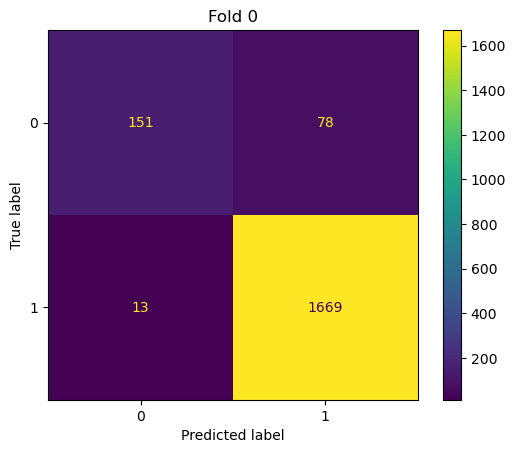

Elapsed time: 770.1 sec


Train: 0.12, Other: 0.88
Test:  0.12, Other: 0.88


{'C': 10, 'kernel': 'linear', 'tol': 0.001}

Test:
Prec = 0.921, Acc = 0.964, Recall = 0.768
Train:
Prec = 0.972, Acc = 0.982, Recall = 0.871


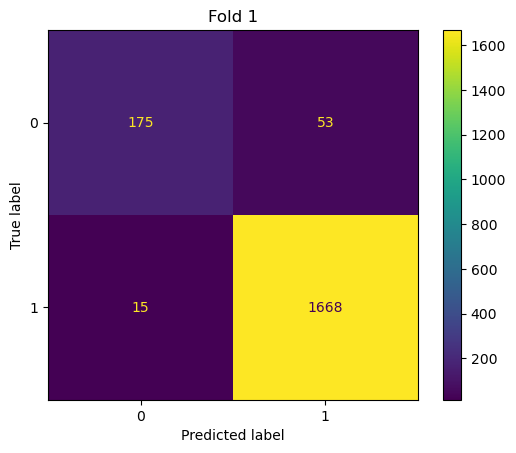

Elapsed time: 594.2 sec


Train: 0.12, Other: 0.88
Test:  0.12, Other: 0.88


{'C': 5, 'kernel': 'linear', 'tol': 0.001}

Test:
Prec = 0.945, Acc = 0.965, Recall = 0.750
Train:
Prec = 0.986, Acc = 0.977, Recall = 0.819


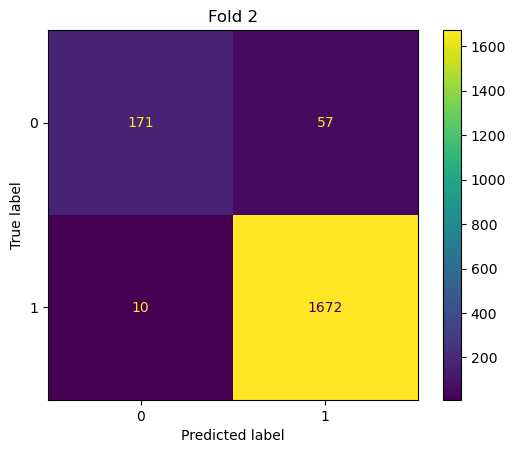

Elapsed time: 529.4 sec


Train: 0.12, Other: 0.88
Test:  0.12, Other: 0.88


{'C': 10, 'kernel': 'linear', 'tol': 0.001}

Test:
Prec = 0.911, Acc = 0.968, Recall = 0.807
Train:
Prec = 0.983, Acc = 0.982, Recall = 0.863


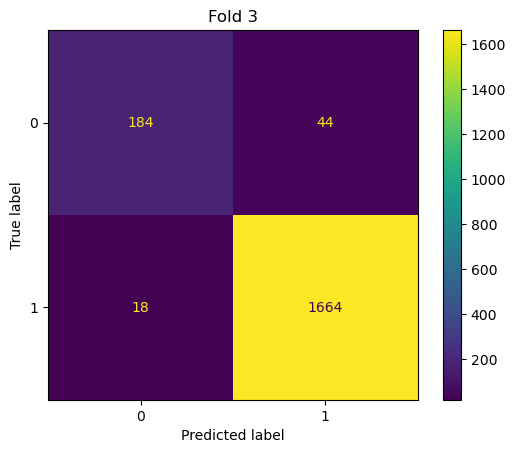

Elapsed time: 491.8 sec


Train: 0.12, Other: 0.88
Test:  0.12, Other: 0.88


{'C': 5, 'kernel': 'linear', 'tol': 0.001}

Test:
Prec = 0.962, Acc = 0.970, Recall = 0.781
Train:
Prec = 0.972, Acc = 0.977, Recall = 0.831


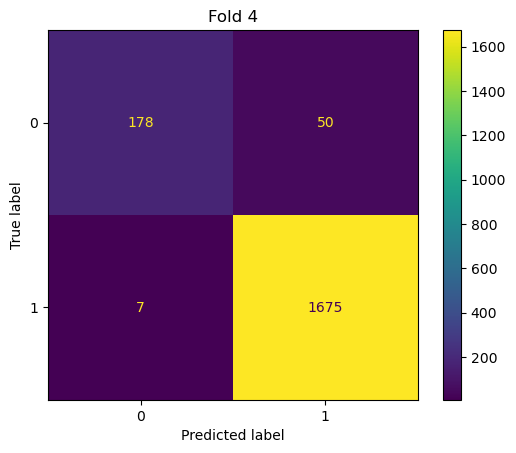

Elapsed time: 384.2 sec



Mean values
Test:
Prec = 0.932, Acc = 0.964, Recall = 0.753
Train:
Prec = 0.978, Acc = 0.979, Recall = 0.843


In [75]:
def_label = 'Franko'

precision_arr, accuracy_arr, recall_arr = [], [], []
precision_arr_train, accuracy_arr_train, recall_arr_train = [], [], []
models_arr, params_arr, vectorizer_arr = [], [], []

for fold in fold_list:
    train_index, test_index = train_ind_arr[fold], test_ind_arr[fold]
    st = time.time()

    x_train, y_train = x[train_index], y[train_index]
    x_test,  y_test  = x[test_index],  y[test_index]

    fr_count = y_train.tolist().count('Franko')
    ot_count = y_train.tolist().count('Other')
    print(f'Train: {fr_count/len(y_train):.2f}, Other: {ot_count/len(y_train):.2f}')
    fr_count = y_test.tolist().count('Franko')
    ot_count = y_test.tolist().count('Other')
    print(f'Test:  {fr_count/len(y_test):.2f}, Other: {ot_count/len(y_test):.2f}')
    
    scorer = make_scorer(accuracy_score)

    CV_class = GridSearchCV(estimator=classifier, param_grid=param_grid, cv=5, n_jobs=-1, scoring=scorer)
    CV_class.fit(x_train, y_train)
    display(CV_class.best_params_)

    y_preds = CV_class.predict(x_test)

    test_precision = precision_score(y_test, y_preds, pos_label=def_label)
    test_accuracy  = accuracy_score(y_test, y_preds)
    test_recall = recall_score(y_test, y_preds, pos_label=def_label)
    precision_arr.append(test_precision)
    accuracy_arr.append(test_accuracy)
    recall_arr.append(test_recall)
    
    y_preds_train = CV_class.predict(x_train)
    train_precision = precision_score(y_train, y_preds_train, pos_label=def_label)
    train_accuracy  = accuracy_score(y_train, y_preds_train)
    train_recall = recall_score(y_train, y_preds_train, pos_label=def_label)
    precision_arr_train.append(train_precision)
    accuracy_arr_train.append(train_accuracy)
    recall_arr_train.append(train_recall)
    
    print('Test:')
    print(f'Prec = {test_precision:.3f}, Acc = {test_accuracy:.3f}, Recall = {test_recall:.3f}')
    print('Train:')
    print(f'Prec = {train_precision:.3f}, Acc = {train_accuracy:.3f}, Recall = {train_recall:.3f}')    

    cm = confusion_matrix(y_test, y_preds)

    ConfusionMatrixDisplay(cm).plot()
    plt.title(f'Fold {fold}')
    plt.show()

    models_arr.append(CV_class)
    params_arr.append(CV_class.best_params_)

    et = time.time()
    print(f'Elapsed time: {et-st:.1f} sec\n\n')

print('\nMean values')
print('Test:')
print(f'Prec = {np.mean(precision_arr):.3f}, Acc = {np.mean(accuracy_arr):.3f}, Recall = {np.mean(recall_arr):.3f}')
print('Train:')
print(f'Prec = {np.mean(precision_arr_train):.3f}, Acc = {np.mean(accuracy_arr_train):.3f}, Recall = {np.mean(recall_arr_train):.3f}')

In [1152]:
ext_dat = '.dat'
ext_sav = '.sav'
params_file = f'models/models{proportion}/franko_params{chunk_length}_{ngram_min}-{ngram_min}{ext_dat}'

with open(params_file, 'a') as file:
    file.write('Mean values\n')
    file.write('Test:\n')
    file.write(f'Prec = {np.mean(precision_arr):.3f}, Acc = {np.mean(accuracy_arr):.3f}, Recall = {np.mean(recall_arr):.3f}')
    file.write('\nTrain:\n')
    file.write(f'Prec = {np.mean(precision_arr_train):.3f}, Acc = {np.mean(accuracy_arr_train):.3f}, Recall = {np.mean(recall_arr_train):.3f}')

    for fold in fold_list:
        model_filename = f'models/models{proportion}/franko_model{chunk_length}_{ngram_min}-{ngram_min}_{fold}{ext_sav}'
        pickle.dump(models_arr[fold], open(model_filename, 'wb'))
        file.write('\n' + str(params_arr[fold]))

# APPLYING MODELS

In [665]:
ngram_min, ngram_max = 2,2
proportion = 87

chunk_length = 500
allowed_tail_fraction = 0.0

dataset = pd.read_csv(f'txt/full{chunk_length}_{proportion}.csv', usecols=['Text', 'Author'])
display(dataset)

,Text,Author
0,Był tu sobie kiedyś Dobrobyt. Nie wiem czy kto...,Franko
1,Ale on ani słuchać nie chciał. — Co mi tam! — ...,Franko
2,"— Ta, proszę pana, jestem Dobrobyt. Pan mię cz...",Franko
3,"— Ba, panie Kreisamcie, a jeżeli ją zginę z gł...",Franko
4,"A teraz powiedz mi, panie Dobrobycie, masz ty ...",Franko
...,...,...
4301,Można było rozróżnić dokładnie czarne kadłuby ...,Other
4302,"Sądziłem, że sam zechcesz zjawić się w moim ar...",Other
4303,Wezwę cię wkrótce znowu. Teraz mam inne sprawy...,Other
4304,Pod nimi z zielonej murawy sterczał głaz jeden...,Other


In [666]:
x = dataset['Text'] # Features
y = dataset['Author']  # Target
fr_count = y.tolist().count('Franko')
ot_count = y.tolist().count('Other')
print(f'Whole set: Franko: {fr_count/len(y):.2f}, Other: {ot_count/len(y):.2f}')

vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(ngram_min,ngram_max))
x = vectorizer.fit_transform(x)

Whole set: Franko: 0.21, Other: 0.79


In [668]:
ext_sav = '.sav1'
loaded_model_arr = []

for fold in range(5):
    model_filename = f'models/models{proportion}/franko_model{chunk_length}_{ngram_min}-{ngram_max}_{fold}{ext_sav}'
    loaded_model = pickle.load(open(model_filename, 'rb'))
    loaded_model_arr.append(loaded_model)

In [669]:
new_path = 'txt/new/'
for input_file in ['DBZK.txt', 
                   'franko-ruskie_czytelnie_ludowe.txt',
                   'franko-nieco_o_sobie_samym.txt',
                   'franko-legenda_o_pilacie.txt',
                   'SK.txt', 'EG.txt',
                   'pol1.txt', 'pol2.txt', 'pol3.txt', 'pol4.txt', 'pol5.txt', 'pol6.txt', 'pol7.txt',
                   'pol2a.txt', 'pol2b.txt',
                   'DBZK_G.txt', 'DBZK_Chat.txt', 'DBZK_Chat2.txt', 'DBZK_Chat3.txt', 'DBZK_Chat5.txt']:

    output_file = new_path + '_processed_'
    output_text = process_text(new_path + input_file, output_file)
    print(len(output_text), 'sentences')

    arr_chunks = split_to_chunks(output_text, chunk_length=chunk_length, allowed_tail_fraction=allowed_tail_fraction)
    print('Number of chunks:', len(arr_chunks))

    to_try = []
    to_try_words = []
    for chunk in arr_chunks:
        sample = ' '.join(chunk)
        to_try.append(sample)
        num_words = count_words_per_text(chunk)
        to_try_words.append(num_words)

    print(input_file)
    i = 0
    x_input_vec = vectorizer.transform(to_try)
    count_Franko, count_Other = 0, 0
    for curr_model in loaded_model_arr:
        y_pred = curr_model.predict(x_input_vec)
        print(i, y_pred)
        count_Franko += np.count_nonzero(y_pred == "Franko")
        count_Other  += np.count_nonzero(y_pred == "Other")
        i += 1
    print(f'Franko: {count_Franko/(count_Franko + count_Other):.2f}, Other: {count_Other/(count_Franko + count_Other):.2f} ')
    print()

124 sentences
Number of chunks: 6
DBZK.txt
0 ['Other' 'Other' 'Franko' 'Other' 'Other' 'Other']
1 ['Other' 'Other' 'Other' 'Other' 'Other' 'Other']
2 ['Other' 'Other' 'Other' 'Franko' 'Other' 'Other']
3 ['Other' 'Other' 'Other' 'Franko' 'Other' 'Other']
4 ['Other' 'Other' 'Other' 'Other' 'Other' 'Other']
Franko: 0.10, Other: 0.90 

19 sentences
Number of chunks: 2
franko-ruskie_czytelnie_ludowe.txt
0 ['Other' 'Franko']
1 ['Other' 'Franko']
2 ['Other' 'Franko']
3 ['Other' 'Franko']
4 ['Other' 'Franko']
Franko: 0.50, Other: 0.50 

65 sentences
Number of chunks: 5
franko-nieco_o_sobie_samym.txt
0 ['Franko' 'Franko' 'Franko' 'Other' 'Other']
1 ['Other' 'Franko' 'Franko' 'Other' 'Franko']
2 ['Franko' 'Franko' 'Franko' 'Other' 'Franko']
3 ['Franko' 'Franko' 'Franko' 'Other' 'Franko']
4 ['Other' 'Franko' 'Franko' 'Other' 'Franko']
Franko: 0.68, Other: 0.32 

37 sentences
Number of chunks: 1
franko-legenda_o_pilacie.txt
0 ['Franko']
1 ['Franko']
2 ['Franko']
3 ['Franko']
4 ['Franko']
Franko: 1

# Result summary

In [1207]:
new_path = 'txt/new/'

new_texts = ['DBZK.txt', 
             'franko-ruskie_czytelnie_ludowe.txt',
             'franko-nieco_o_sobie_samym.txt',
             'franko-legenda_o_pilacie.txt',
             'SK.txt', 
             'EG.txt',
             'pol1.txt', 'pol2.txt', 'pol3.txt', 'pol4.txt', 'pol5.txt', 'pol6.txt', 'pol7.txt',
             'pol2a.txt', 'pol2b.txt',
             'DBZK_G.txt', 'DBZK_Chat.txt', 'DBZK_Chat2.txt', 'DBZK_Chat3.txt', 'DBZK_Chat5.txt']

chunk_length_arr = [200, 250, 300, 400, 500]

prop_arr = [64, 78, 87]
num_props = len(prop_arr)

DBZK.txt


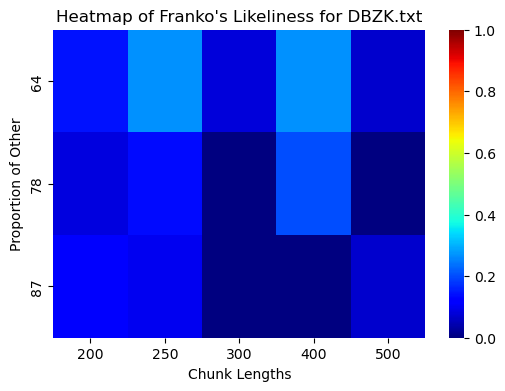

franko-ruskie_czytelnie_ludowe.txt


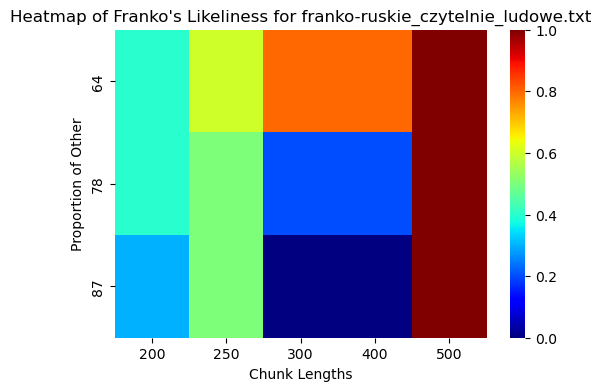

franko-nieco_o_sobie_samym.txt


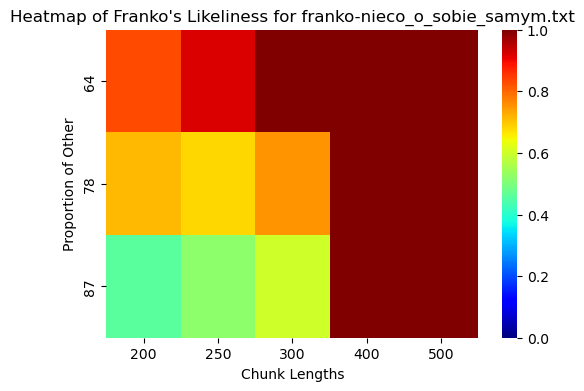

franko-legenda_o_pilacie.txt


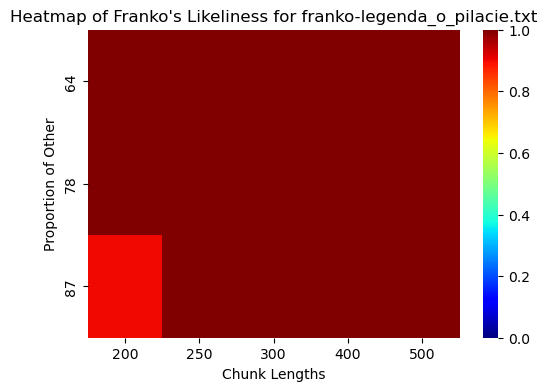

SK.txt


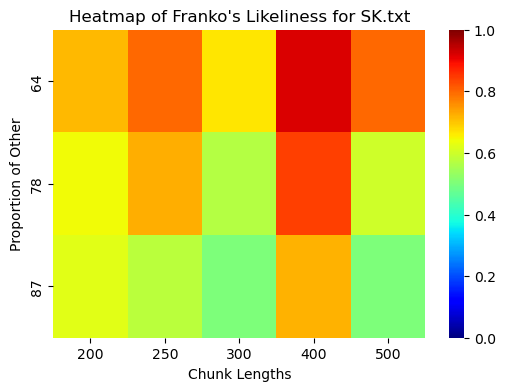

EG.txt


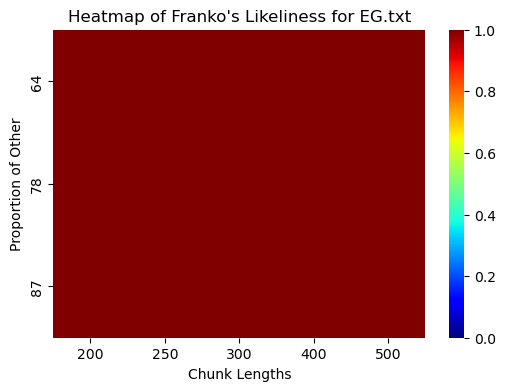

pol1.txt


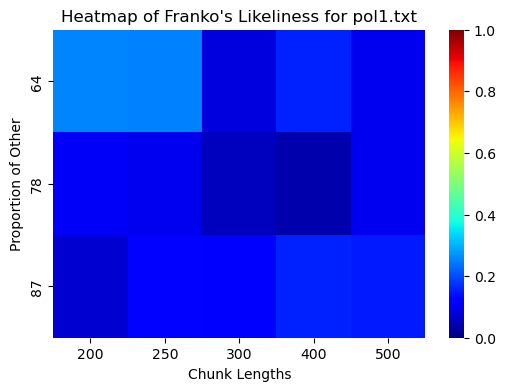

pol2.txt


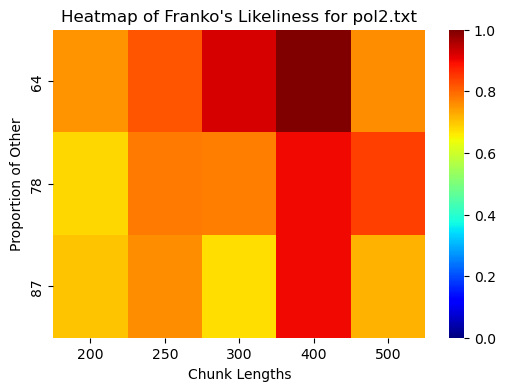

pol3.txt


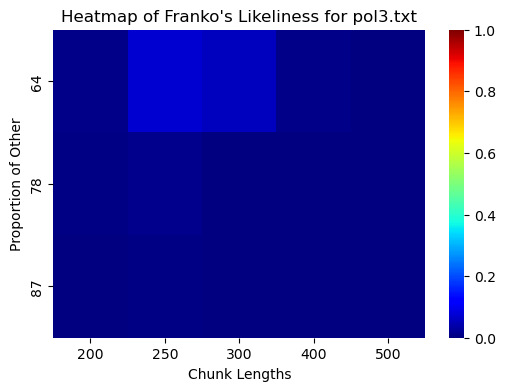

pol4.txt


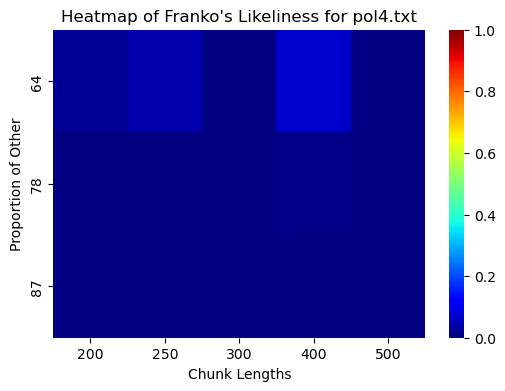

pol5.txt


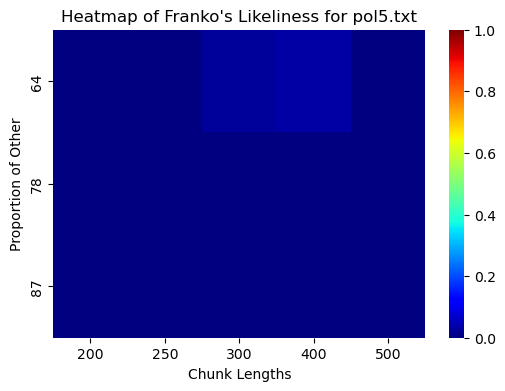

pol6.txt


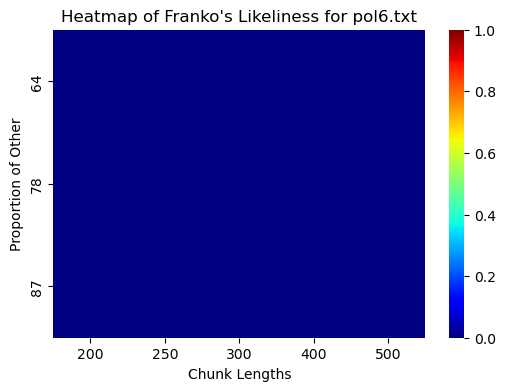

pol7.txt


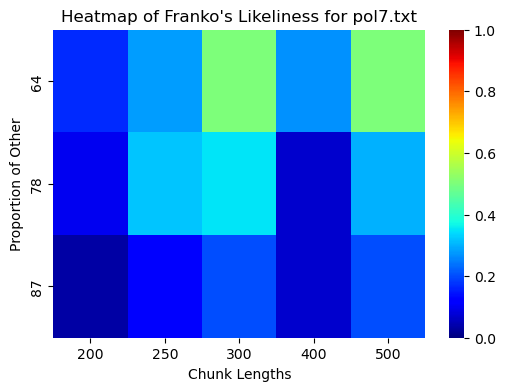

pol2a.txt


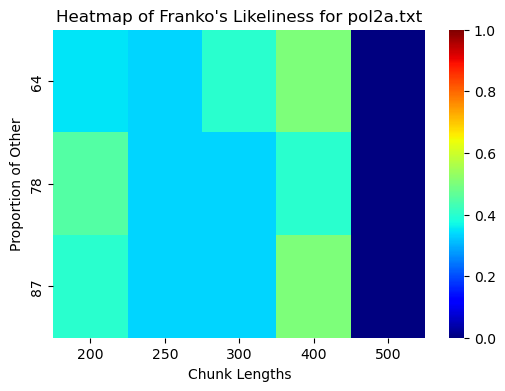

pol2b.txt


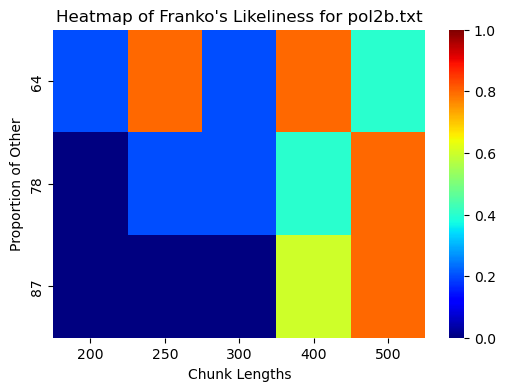

DBZK_G.txt


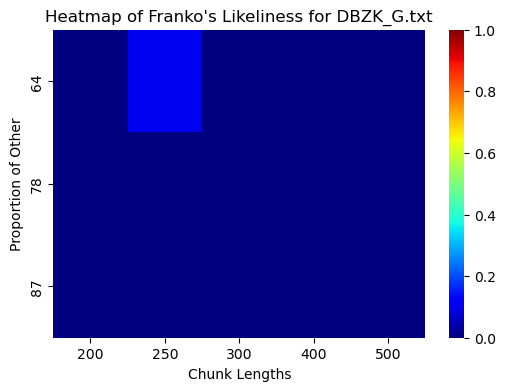

DBZK_Chat.txt


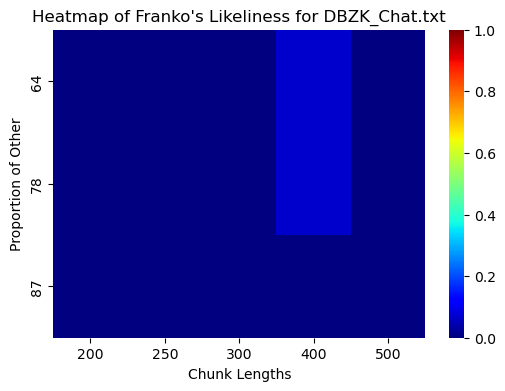

DBZK_Chat2.txt


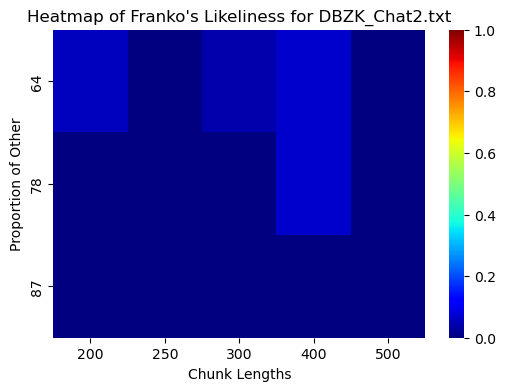

DBZK_Chat3.txt


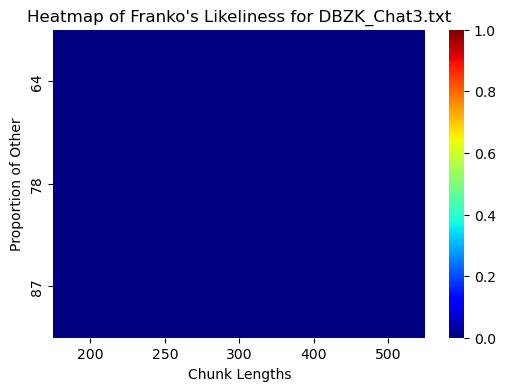

DBZK_Chat5.txt


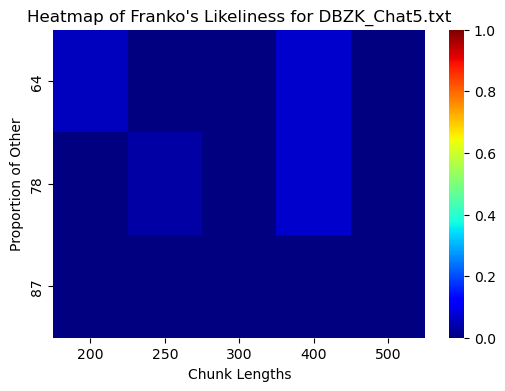

In [1208]:
ngram_min, ngram_max = 2,2
allowed_tail_fraction = 0.0
ext_sav = '.sav'

heatmap_matrices = []

for input_file in new_texts:
    print(input_file)
    distance_matrix = np.zeros((num_props, len(chunk_length_arr)))

    xi_prop = 0
    for proportion in prop_arr:
        yj_chunk = 0
        for chunk_length in chunk_length_arr:
            print(f'{xi_prop} {yj_chunk}\r', end='')
            dataset = pd.read_csv(f'txt/full{chunk_length}_{proportion}.csv', 
                                  usecols=['Text', 'Author'])

            x = dataset['Text'] # Features
            y = dataset['Author']  # Target
            fr_count = y.tolist().count('Franko')
            ot_count = y.tolist().count('Other')
            
            vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(ngram_min,ngram_max))
            x = vectorizer.fit_transform(x)
            
            loaded_model_arr = []

            for fold in range(5):
                model_filename = f'models/models{proportion:2d}/franko_model{chunk_length}_{ngram_min}-{ngram_max}_{fold}{ext_sav}'
                loaded_model = pickle.load(open(model_filename, 'rb'))
                loaded_model_arr.append(loaded_model)
            
            output_file = new_path + '_processed_'
            output_text = process_text(new_path + input_file, output_file)

            arr_chunks = split_to_chunks(output_text, chunk_length=chunk_length, 
                                         allowed_tail_fraction=allowed_tail_fraction)

            to_try = []
            to_try_words = []
            for chunk in arr_chunks:
                sample = ' '.join(chunk)
                to_try.append(sample)
                num_words = count_words_per_text(chunk)
                to_try_words.append(num_words)

            i = 0
            x_input_vec = vectorizer.transform(to_try)
            count_Franko, count_Other = 0, 0
            for curr_model in loaded_model_arr:
                y_pred = curr_model.predict(x_input_vec)
                count_Franko += np.count_nonzero(y_pred == "Franko")
                count_Other  += np.count_nonzero(y_pred == "Other")
                i += 1

            pred_Franko = count_Franko / (count_Franko + count_Other)
                        
            distance_matrix[xi_prop, yj_chunk] = pred_Franko
            
            yj_chunk += 1
        xi_prop += 1
        
    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(distance_matrix, annot=False, cmap='jet', vmin=0, vmax=1,
                xticklabels=chunk_length_arr,
                yticklabels=prop_arr,
               )
    plt.title(f"Heatmap of Franko's Likeliness for {input_file}")
    plt.xlabel("Chunk Lengths")
    plt.ylabel("Proportion of Other")
    plt.show()
    
    heatmap_matrices.append(distance_matrix)

In [1209]:
# Save to disk
np.save('heatmaps_random.npy', heatmap_matrices)

In [580]:
# Load from disk
heatmaps = np.load('heatmaps_random.npy')

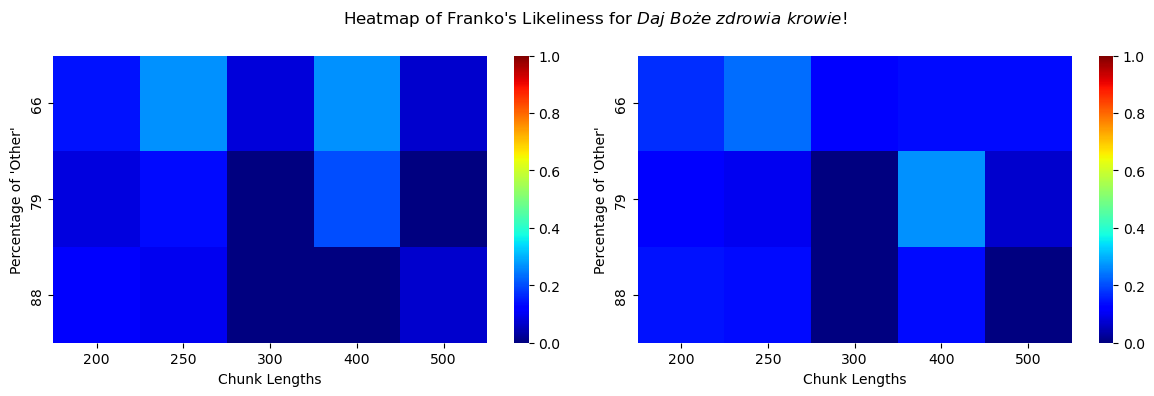

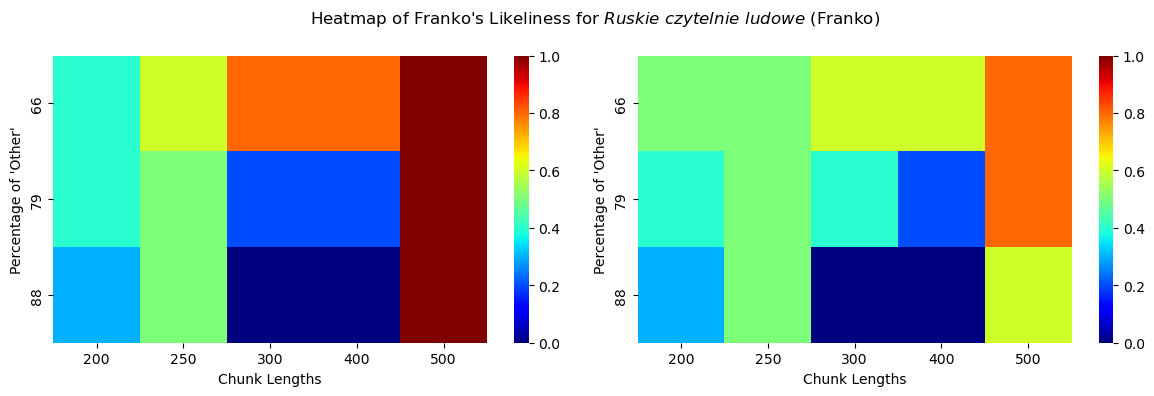

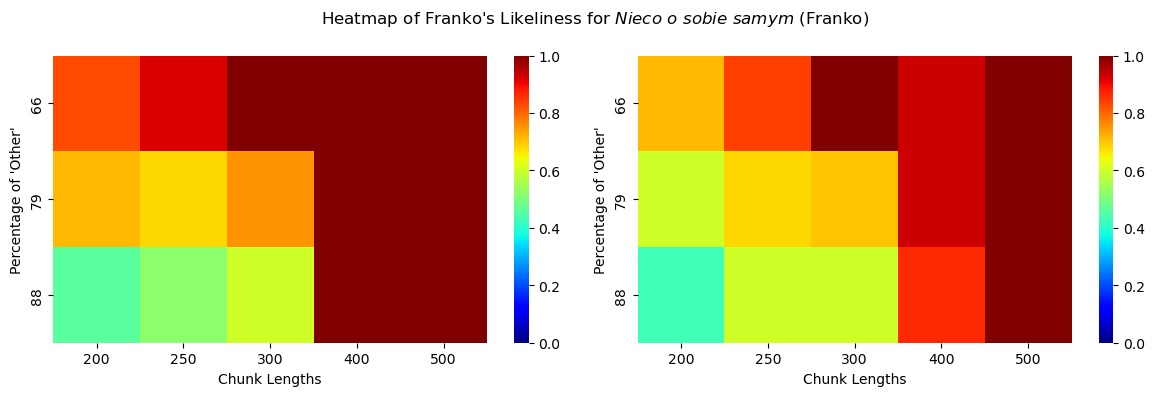

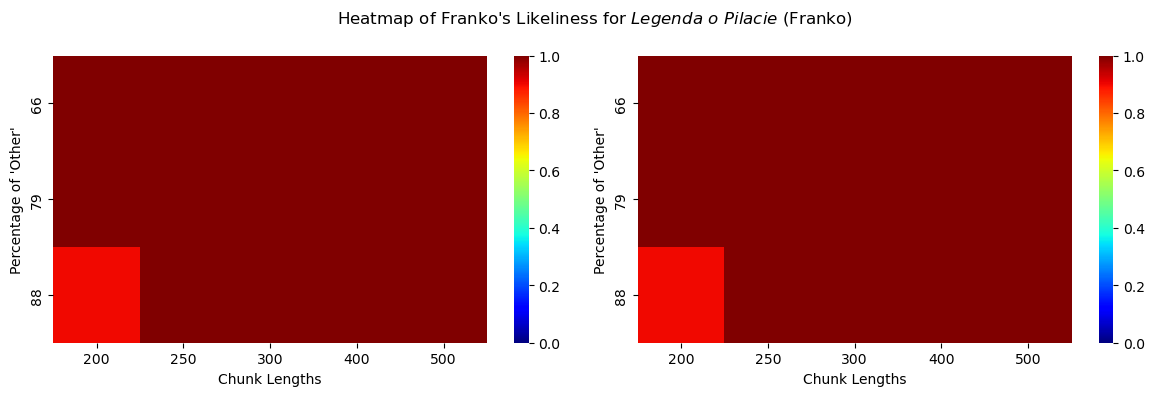

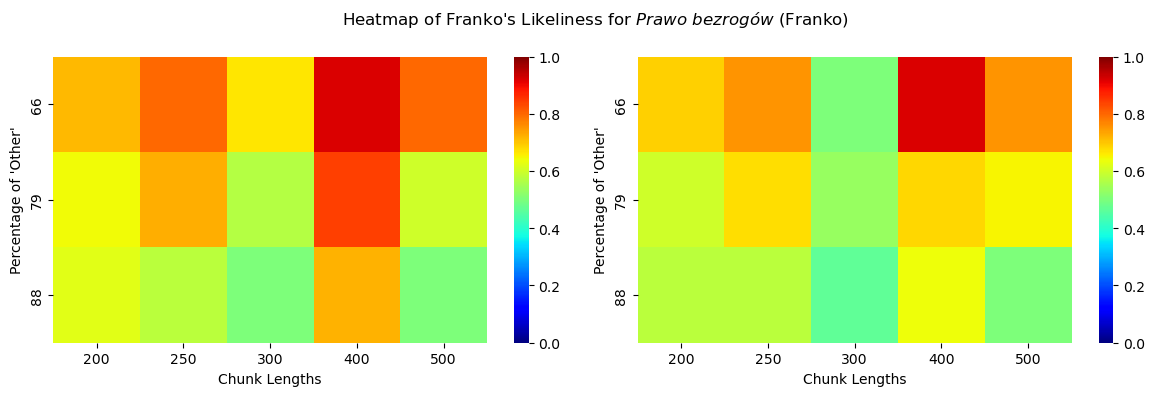

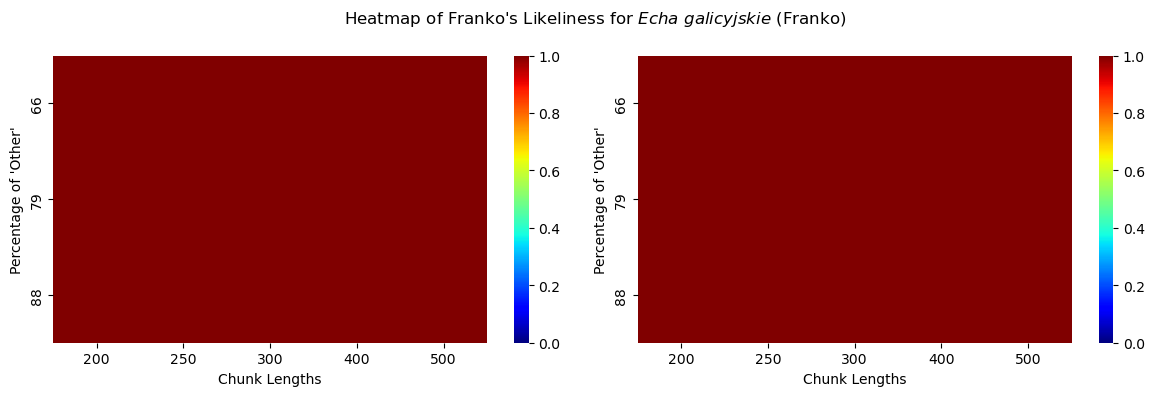

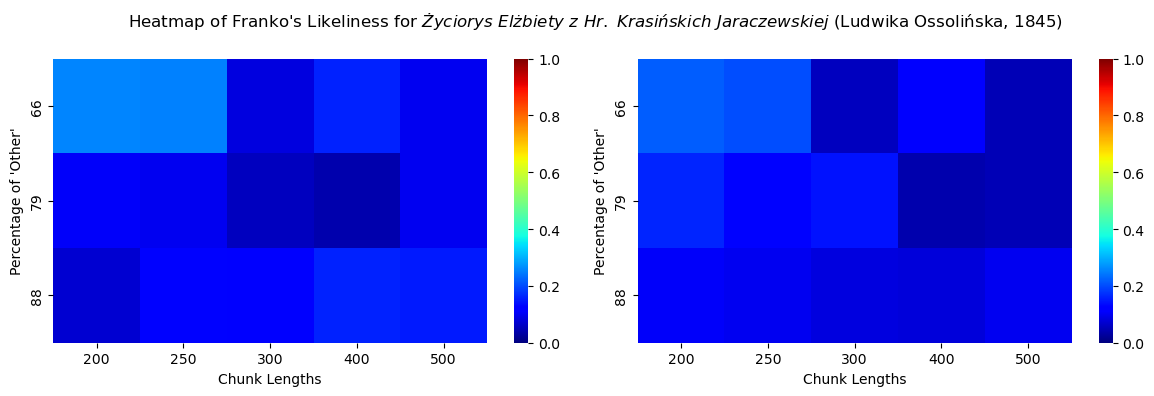

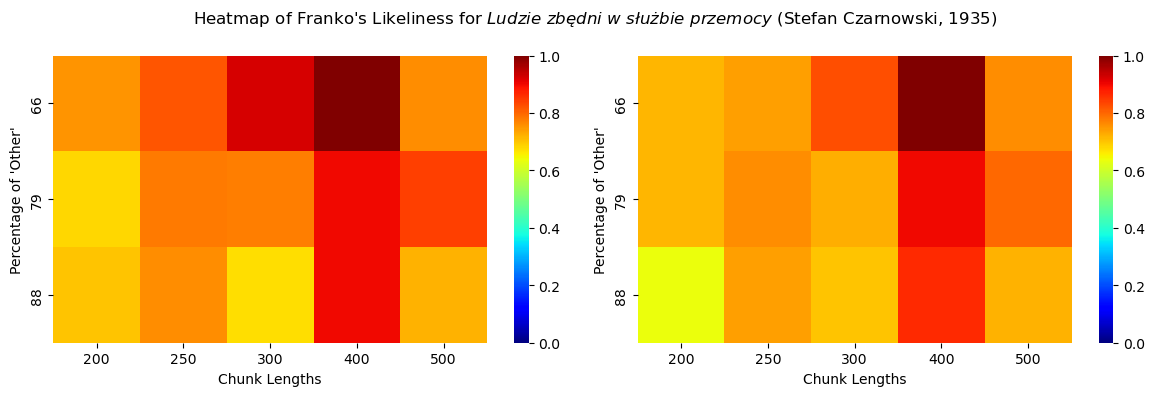

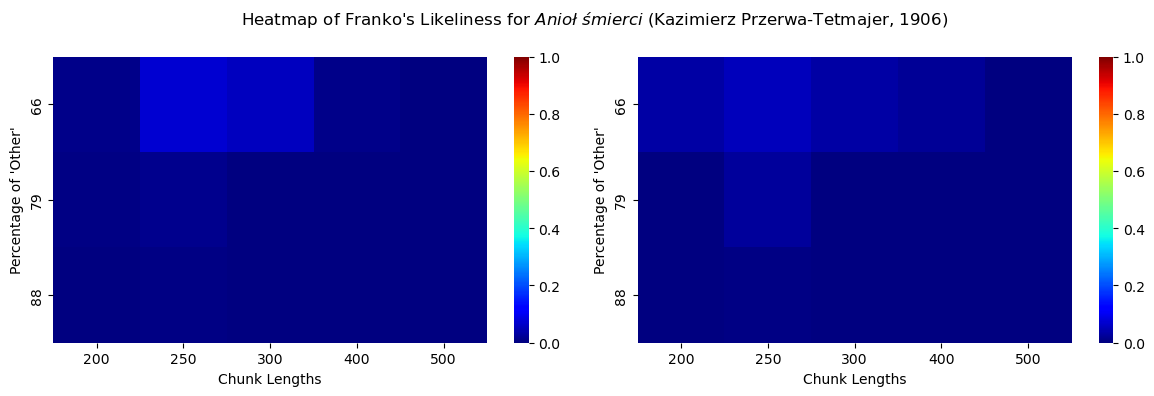

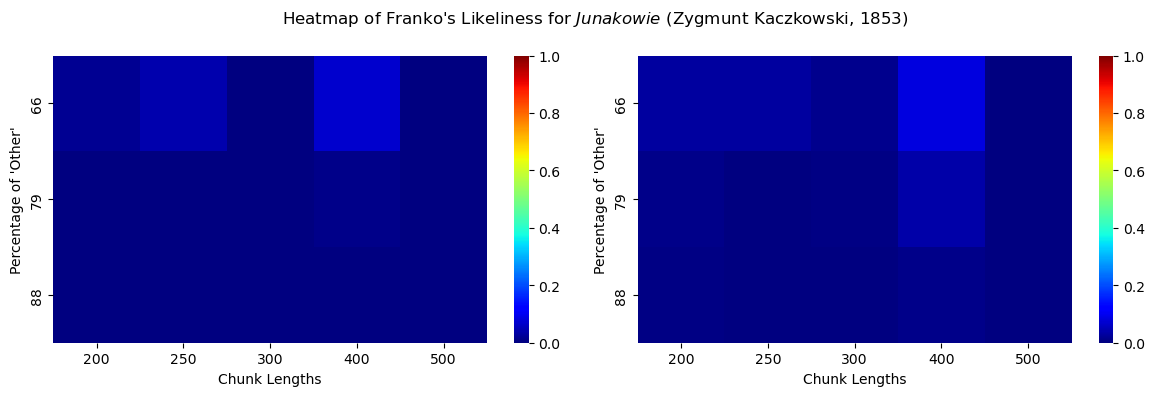

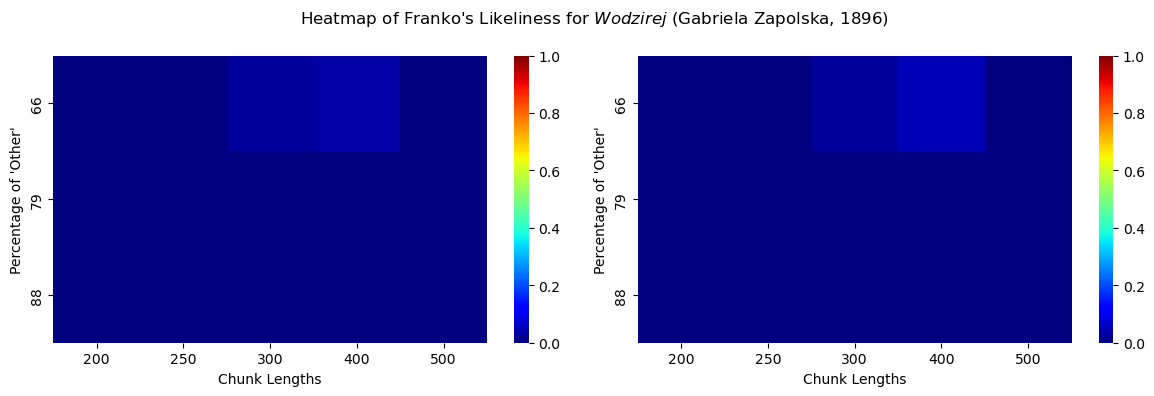

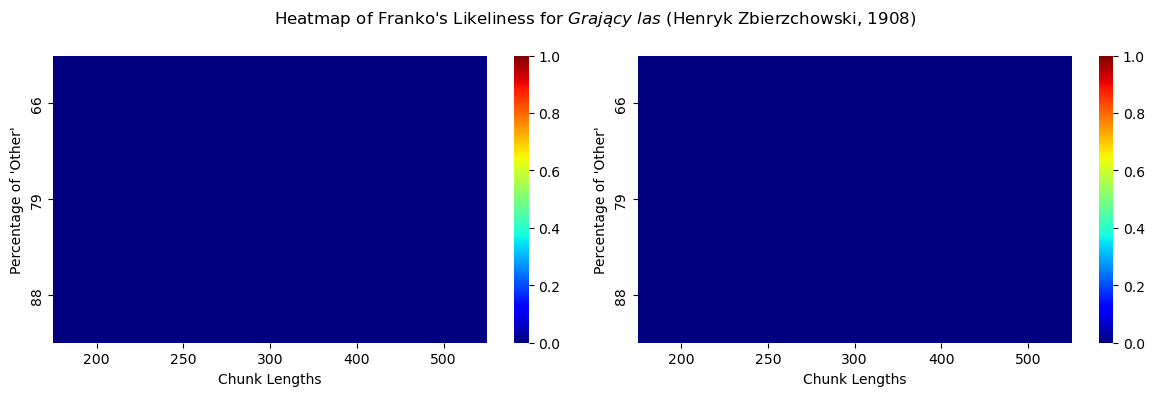

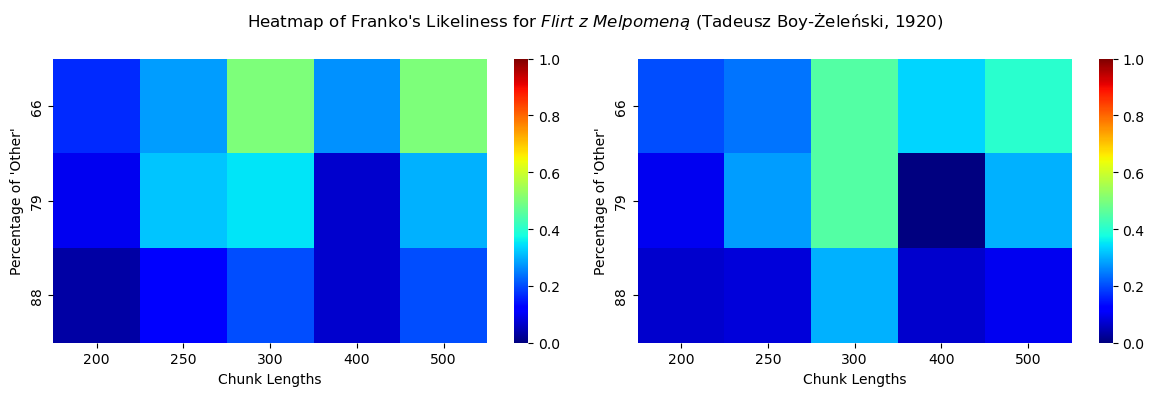

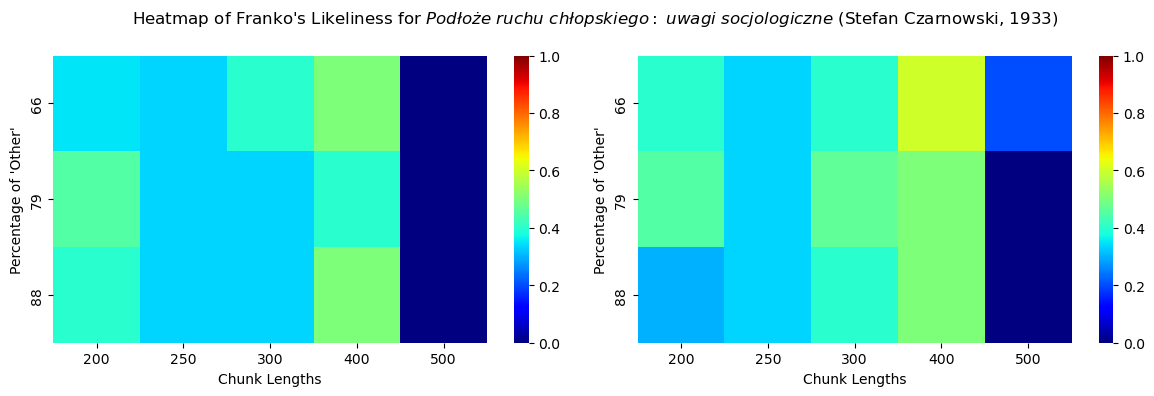

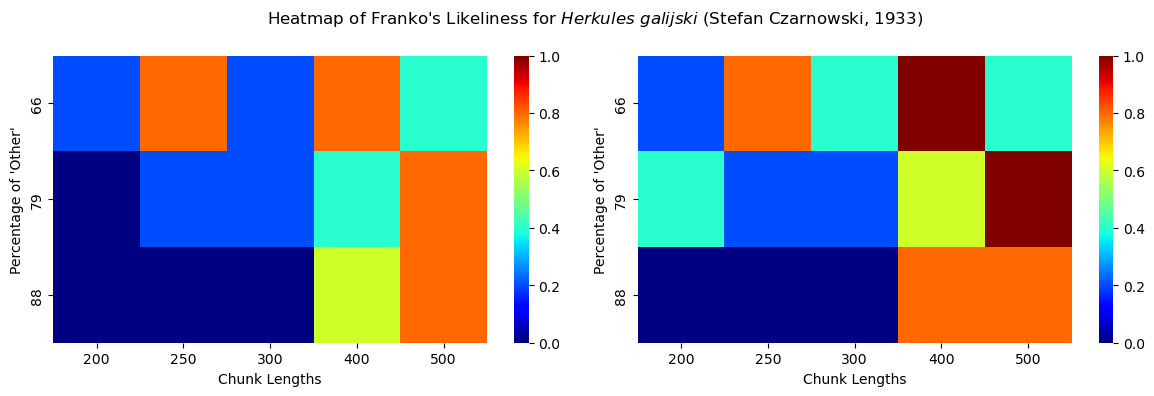

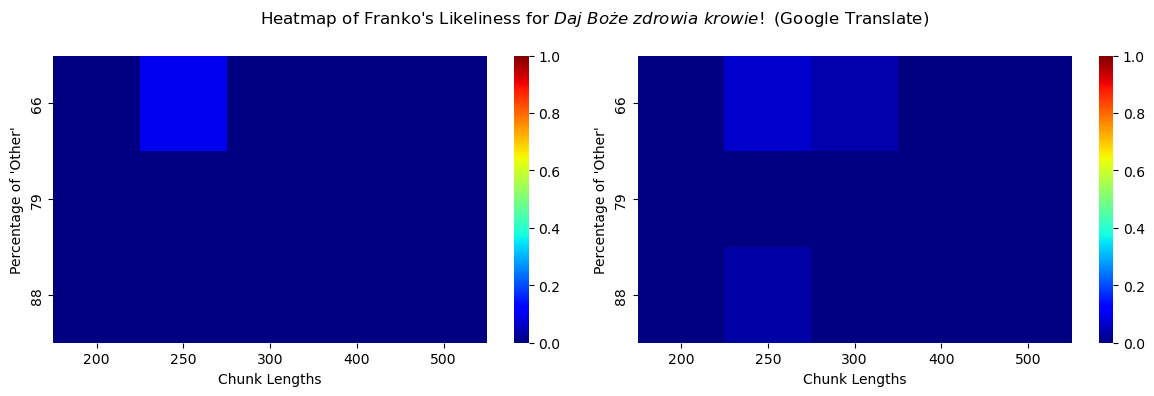

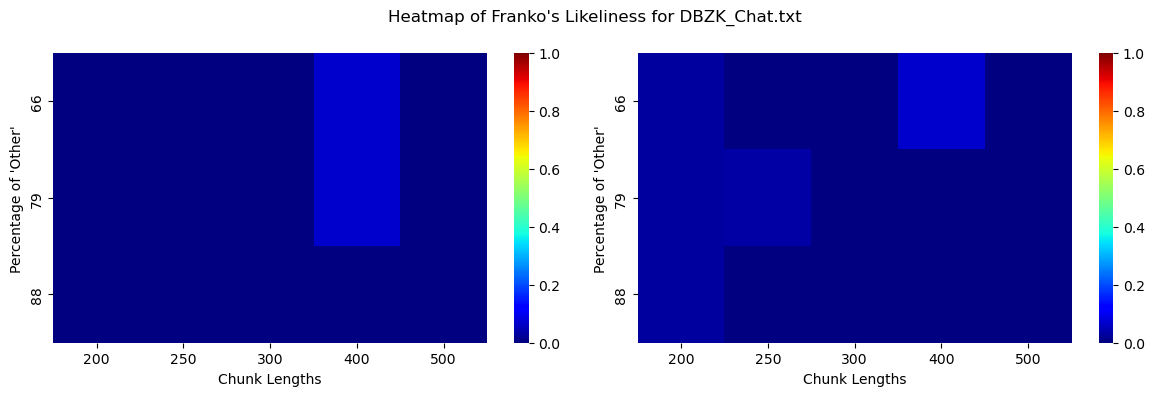

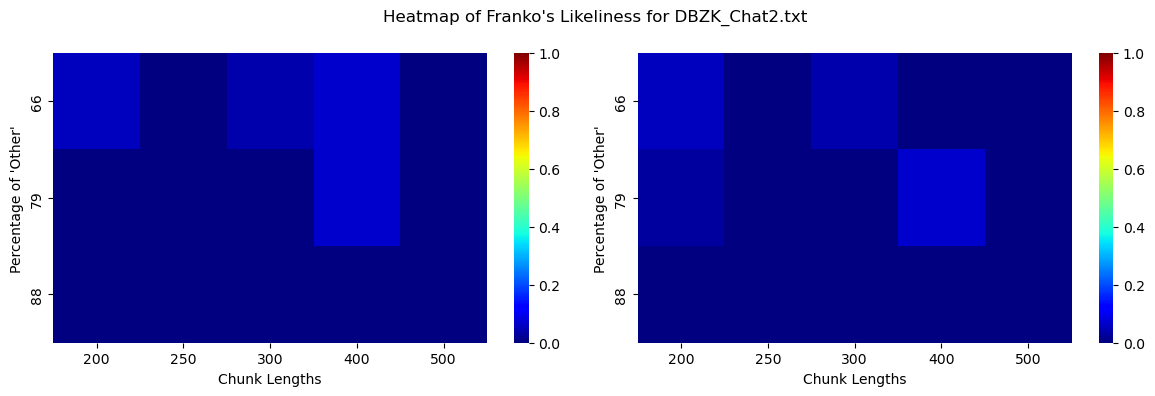

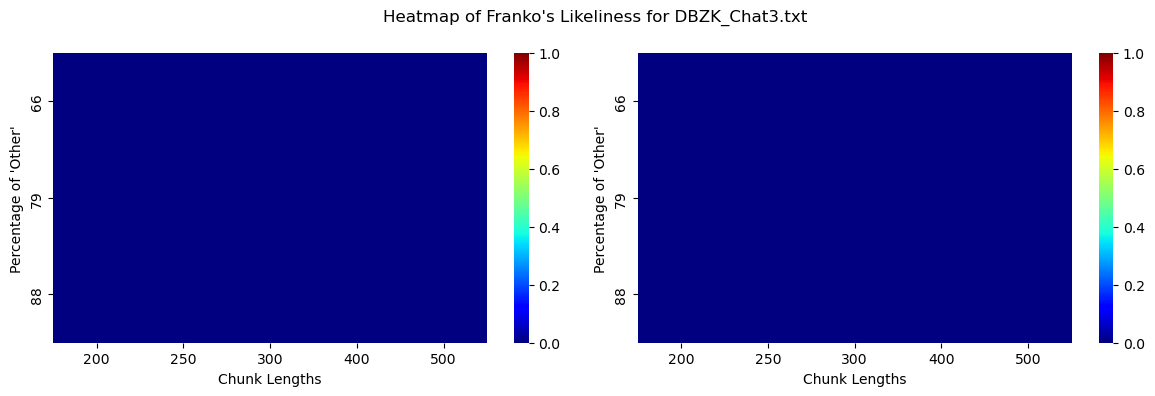

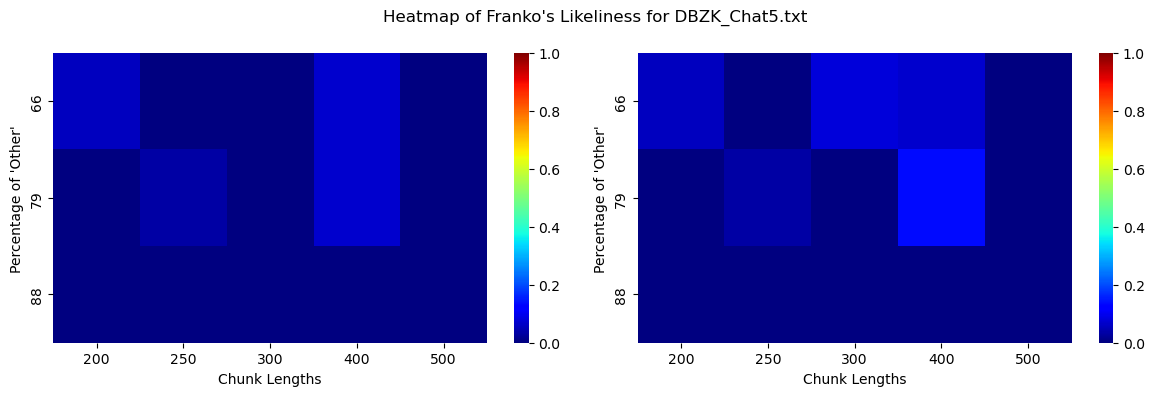

In [1229]:
new_texts_nice = [r'$Daj\ Boże\ zdrowia\ krowie!$', 
                  r'$Ruskie\ czytelnie\ ludowe$ (Franko)',
                  r'$Nieco\ o\ sobie\ samym$ (Franko)',
                  r'$Legenda\ o\ Pilacie$ (Franko)',
                  r'$Prawo\ bezrogów$ (Franko)',
                  r'$Echa\ galicyjskie$ (Franko)',
                  r'$Życiorys\ Elżbiety\ z\ Hr.\ Krasińskich\ Jaraczewskiej$ (Ludwika Ossolińska, 1845)',
                  r'$Ludzie\ zbędni\ w\ służbie\ przemocy$ (Stefan Czarnowski, 1935)',
                  r'$Anioł\ śmierci$ (Kazimierz Przerwa-Tetmajer, 1906)',
                  r'$Junakowie$ (Zygmunt Kaczkowski, 1853)',
                  r'$Wodzirej$ (Gabriela Zapolska, 1896)',
                  r'$Grający\ las$ (Henryk Zbierzchowski, 1908)',
                  r'$Flirt\ z\ Melpomeną$ (Tadeusz Boy-Żeleński, 1920)',
                  r'$Podłoże\ ruchu\ chłopskiego:\ uwagi\ socjologiczne$ (Stefan Czarnowski, 1933)',
                  r'$Herkules\ galijski$ (Stefan Czarnowski, 1933)',
                  r'$Daj\ Boże\ zdrowia\ krowie!$ (Google Translate)',
                  'DBZK_Chat.txt', 'DBZK_Chat2.txt', 'DBZK_Chat3.txt', 'DBZK_Chat5.txt']

chunk_length_arr = [200, 250, 300, 400, 500]
prop_arr = [66, 79, 88]

heatmaps_random = np.load('heatmaps_random.npy')
heatmaps_texts  = np.load('heatmaps_texts.npy')

for (hm1, hm2, input_file) in zip(heatmaps_random, heatmaps_texts, new_texts_nice):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
    
    sns.heatmap(hm1, annot=False, cmap='jet', vmin=0, vmax=1,
                xticklabels=chunk_length_arr, 
                yticklabels=prop_arr,
                ax=axes[0]
               )
    sns.heatmap(hm2, annot=False, cmap='jet', vmin=0, vmax=1,
                xticklabels=chunk_length_arr, 
                yticklabels=prop_arr,
                ax=axes[1]
               )
    fig.suptitle(f"Heatmap of Franko's Likeliness for {input_file}")
    axes[0].set_xlabel("Chunk Lengths")
    axes[0].set_ylabel("Percentage of 'Other'")
    axes[1].set_xlabel("Chunk Lengths")
    axes[1].set_ylabel("Percentage of 'Other'")
    plt.tight_layout()
    plt.show()


# Result summary

In [895]:
new_path = 'txt/new/'

new_texts = ['DBZK.txt', 
             'franko-ruskie_czytelnie_ludowe.txt',
             'franko-nieco_o_sobie_samym.txt',
             'franko-legenda_o_pilacie.txt',
             'SK.txt', 
             'EG.txt',
             'pol1.txt', 'pol2.txt', 'pol3.txt', 'pol4.txt', 'pol5.txt', 'pol6.txt', 'pol7.txt',
             'pol2a.txt', 'pol2b.txt',
             'DBZK_G.txt', 'DBZK_Chat.txt', 'DBZK_Chat2.txt', 'DBZK_Chat3.txt', 'DBZK_Chat5.txt']

chunk_length_arr = [200, 250, 300, 400, 500]

prop_arr = [64, 78, 87]
num_props = len(prop_arr)

DBZK.txt


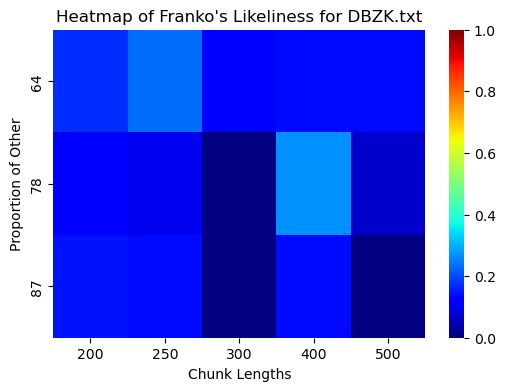

franko-ruskie_czytelnie_ludowe.txt


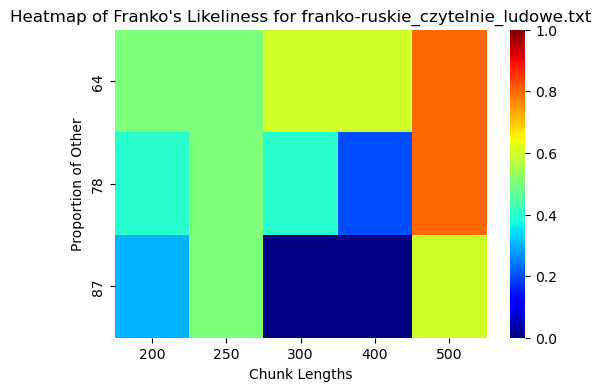

franko-nieco_o_sobie_samym.txt


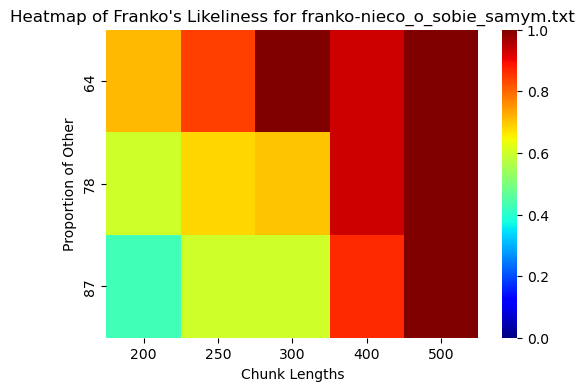

franko-legenda_o_pilacie.txt


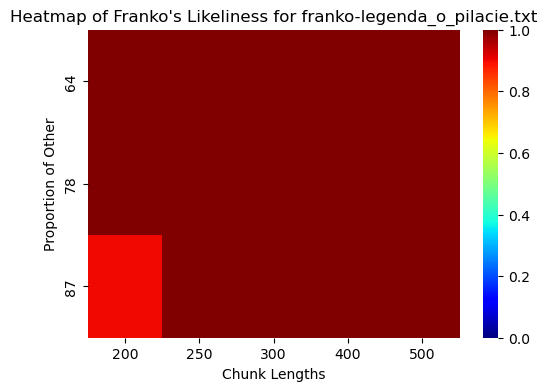

SK.txt


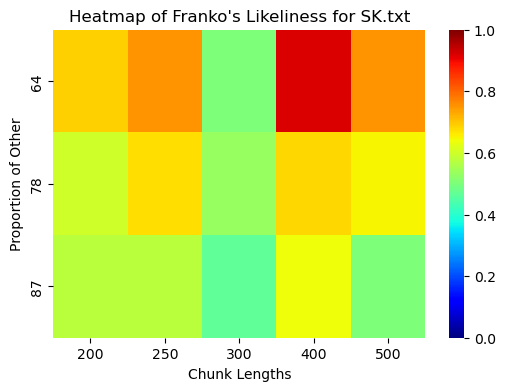

EG.txt


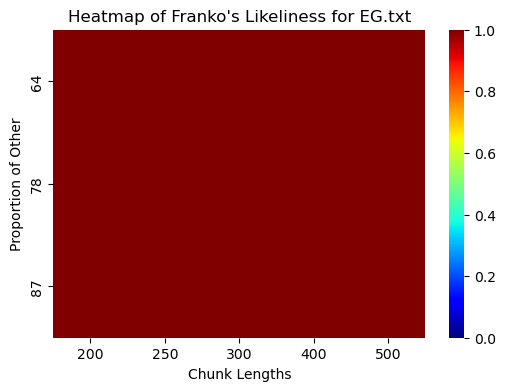

pol1.txt


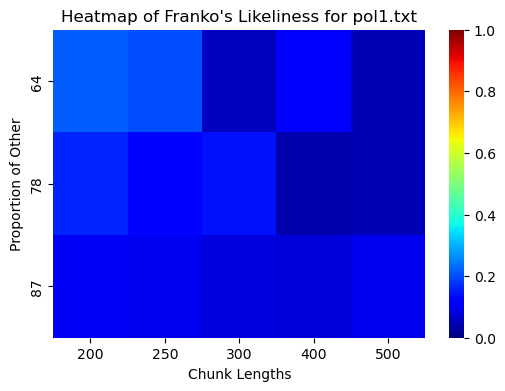

pol2.txt


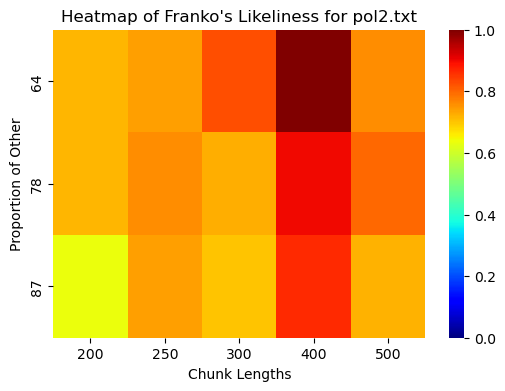

pol3.txt


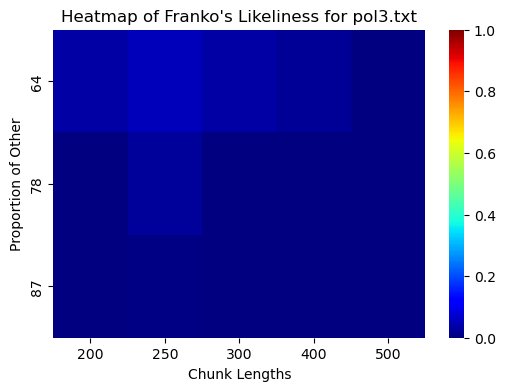

pol4.txt


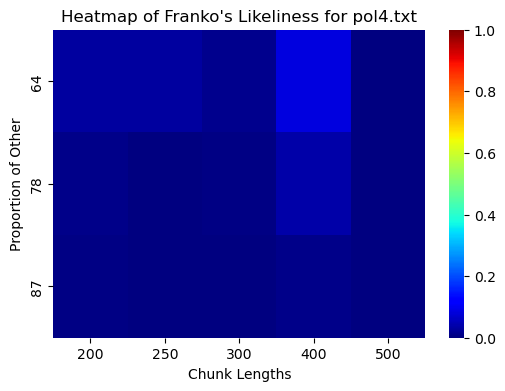

pol5.txt


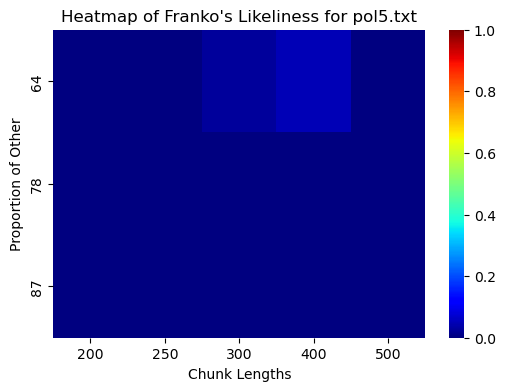

pol6.txt


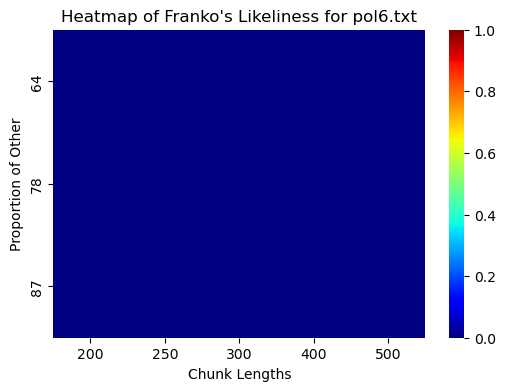

pol7.txt


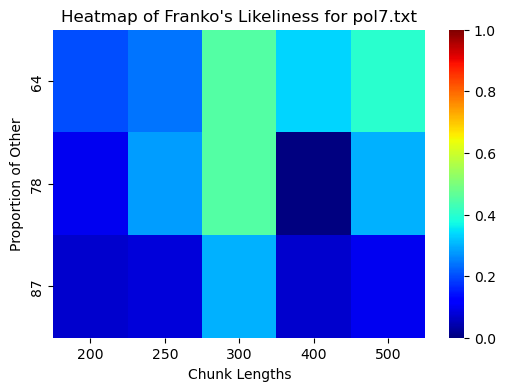

pol2a.txt


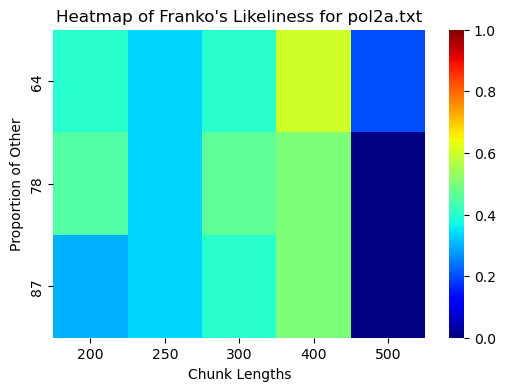

pol2b.txt


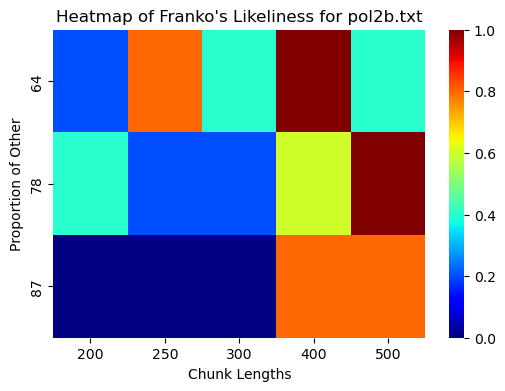

DBZK_G.txt


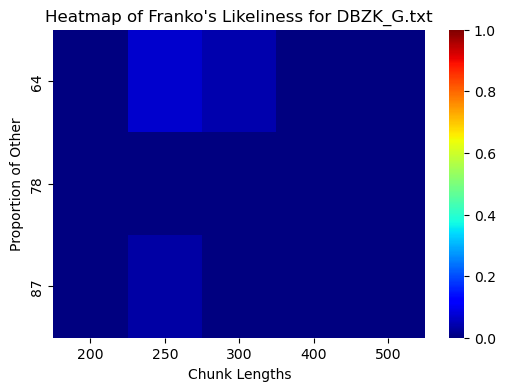

DBZK_Chat.txt


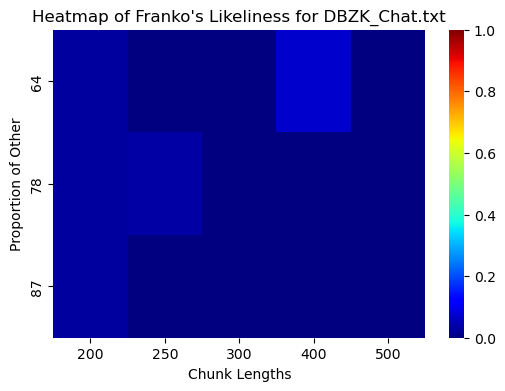

DBZK_Chat2.txt


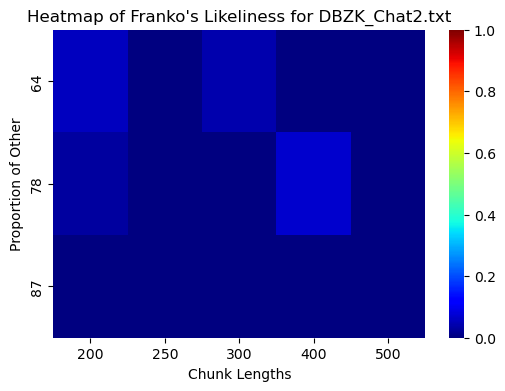

DBZK_Chat3.txt


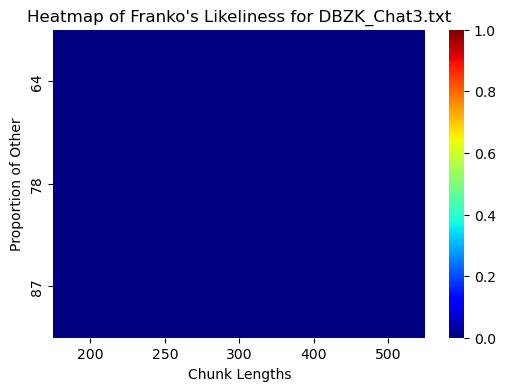

DBZK_Chat5.txt


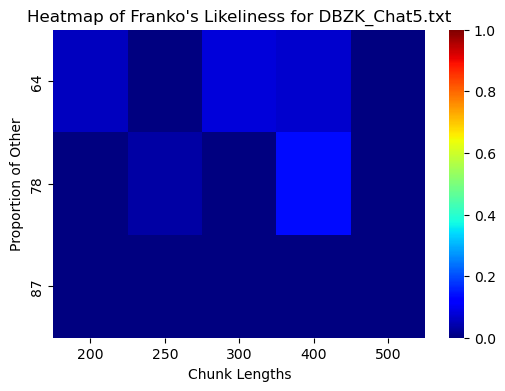

In [896]:
ngram_min, ngram_max = 2,2
allowed_tail_fraction = 0.0
ext_sav = '.sav1'

heatmap_matrices1 = []

for input_file in new_texts:
    print(input_file)
    distance_matrix = np.zeros((num_props, len(chunk_length_arr)))

    xi_prop = 0
    for proportion in prop_arr:
        yj_chunk = 0
        for chunk_length in chunk_length_arr:
            print(f'{xi_prop} {yj_chunk}\r', end='')
            dataset = pd.read_csv(f'txt/full{chunk_length}_{proportion}.csv', 
                                  usecols=['Text', 'Author'])

            x = dataset['Text'] # Features
            y = dataset['Author']  # Target
            fr_count = y.tolist().count('Franko')
            ot_count = y.tolist().count('Other')

            vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(ngram_min,ngram_max))
            x = vectorizer.fit_transform(x)
            
            loaded_model_arr = []

            for fold in range(5):
                model_filename = f'models/models{proportion:2d}/franko_model{chunk_length}_{ngram_min}-{ngram_max}_{fold}{ext_sav}'
                loaded_model = pickle.load(open(model_filename, 'rb'))
                loaded_model_arr.append(loaded_model)
            
            output_file = new_path + '_processed_'
            output_text = process_text(new_path + input_file, output_file)

            arr_chunks = split_to_chunks(output_text, chunk_length=chunk_length, 
                                         allowed_tail_fraction=allowed_tail_fraction)

            to_try = []
            to_try_words = []
            for chunk in arr_chunks:
                sample = ' '.join(chunk)
                to_try.append(sample)
                num_words = count_words_per_text(chunk)
                to_try_words.append(num_words)

            i = 0
            x_input_vec = vectorizer.transform(to_try)
            count_Franko, count_Other = 0, 0
            for curr_model in loaded_model_arr:
                y_pred = curr_model.predict(x_input_vec)
                count_Franko += np.count_nonzero(y_pred == "Franko")
                count_Other  += np.count_nonzero(y_pred == "Other")
                i += 1

            pred_Franko = count_Franko / (count_Franko + count_Other)
                        
            distance_matrix[xi_prop, yj_chunk] = pred_Franko
            
            yj_chunk += 1
        xi_prop += 1
        
    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(distance_matrix, annot=False, cmap='jet', vmin=0, vmax=1,
                xticklabels=chunk_length_arr, 
                yticklabels=prop_arr,
               )
    plt.title(f"Heatmap of Franko's Likeliness for {input_file}")
    plt.xlabel("Chunk Lengths")
    plt.ylabel("Proportion of Other")
    plt.show()
    
    heatmap_matrices1.append(distance_matrix)

In [897]:
# Save to disk
np.save('heatmaps_texts.npy', heatmap_matrices1)